<a href="https://colab.research.google.com/github/Meytardzhevtd/ml-course/blob/main/hw_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
!pip install ucimlrepo
!pip install -q ucimlrepo imbalanced-learn

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

bank = fetch_ucirepo(id=222)
df = pd.concat([bank.data.features, bank.data.targets], axis=1)  # склеиваем признаки и цель в одну таблицу

print(df.shape)
print(df.isna().sum())
df.head()

(45211, 17)
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [5]:
print("Минимум:", df["day_of_week"].min())
print("Максимум:", df["day_of_week"].max())
print("Уникальных значений:", df["day_of_week"].nunique())
print(sorted(df["day_of_week"].unique()))

Минимум: 1
Максимум: 31
Уникальных значений: 31
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]


In [6]:
# По описанию UCI (п. 10) и проверке выше (значения 1–31) это день месяца, а не день недели
df = df.rename(columns={"day_of_week": "day"})
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

## 1. Описание данных

**Источник.** Данные прямых маркетинговых кампаний португальского банка (Moro, Cortez, Rita, 2014). UCI Machine Learning Repository, ID 222, лицензия CC BY 4.0. Загружаются из кода через библиотеку `ucimlrepo`.

**Как устроены данные.** Банк обзванивал клиентов и предлагал открыть срочный вклад; одному клиенту могли звонить несколько раз. По описанию UCI записи упорядочены по времени (май 2008 — ноябрь 2010), но год в данных не указан.

**Объект** — один клиент, 45 211 строк. **Целевая переменная** — `y`: открыл ли клиент вклад (yes/no). **Задача** — бинарная классификация.

**Почему задача осмысленна.** Каждый звонок стоит денег (время оператора), а лишние звонки раздражают клиентов. Модель, которая заранее оценивает вероятность согласия, позволяет звонить в первую очередь тем, кто вероятнее согласится.

### Признаки

| Признак | Смысл | Тип | Единицы / значения |
|---|---|---|---|
| `age` | возраст клиента | числовой | лет |
| `job` | тип занятости | категориальный | admin., blue-collar, management, student, retired и др. |
| `marital` | семейное положение | категориальный | married / single / divorced (divorced включает вдовцов) |
| `education` | уровень образования | категориальный | primary / secondary / tertiary |
| `default` | есть ли просроченный кредит | бинарный | yes / no |
| `balance` | среднегодовой баланс на счёте | числовой | евро |
| `housing` | есть ли ипотека | бинарный | yes / no |
| `loan` | есть ли потребительский кредит | бинарный | yes / no |
| `contact` | тип связи при последнем звонке | категориальный | cellular / telephone |
| `day` | день месяца последнего звонка* | числовой | 1–31 |
| `month` | месяц последнего звонка | категориальный | jan – dec |
| `duration` | длительность последнего звонка | числовой | секунды |
| `campaign` | число звонков клиенту в текущей кампании, включая последний | числовой | штук |
| `pdays` | дней прошло с последнего звонка в прошлой кампании | числовой | дней; −1 = раньше не звонили |
| `previous` | число звонков клиенту до текущей кампании | числовой | штук |
| `poutcome` | итог прошлой кампании | категориальный | success / failure / other |
| `y` | **цель**: открыл ли вклад | бинарный | yes / no |

\* В Python-версии датасета столбец называется `day_of_week`, но по описанию UCI (п. 10) и по значениям (1–31, проверено ниже) это день месяца. Переименован в `day`.

**Важно:** `duration` становится известна только после звонка, а решение, звонить ли клиенту, банк принимает до него. Это потенциальная утечка; подробно разбирается в разделе «Анализ утечки».

In [7]:
print("Размер таблицы (строк, столбцов):", df.shape)
print()
print(df.dtypes.astype(str).value_counts())

overview = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "уникальных": df.nunique(),
    "пропусков": df.isna().sum(),
    "доля пропусков, %": (df.isna().mean() * 100).round(2),
}).sort_values("доля пропусков, %", ascending=False)

overview

Размер таблицы (строк, столбцов): (45211, 17)

object    10
int64      7
Name: count, dtype: int64


,тип,уникальных,пропусков,"доля пропусков, %"
poutcome,object,3,36959,81.75
contact,object,2,13020,28.80
education,object,3,1857,4.11
job,object,11,288,0.64
age,int64,77,0,0.00
default,object,2,0,0.00
balance,int64,7168,0,0.00
housing,object,2,0,0.00
marital,object,3,0,0.00
loan,object,2,0,0.00


In [8]:
no_prev = (df["pdays"] == -1)

print("Клиентов с pdays = -1 (раньше не звонили):", no_prev.sum(),
      f"({no_prev.mean() * 100:.1f}%)")
print("Из них с previous = 0:", (no_prev & (df["previous"] == 0)).sum())
print("Из них с пропуском в poutcome:", (no_prev & df["poutcome"].isna()).sum())

Клиентов с pdays = -1 (раньше не звонили): 36954 (81.7%)
Из них с previous = 0: 36954
Из них с пропуском в poutcome: 36954


In [9]:
df["y"] = (df["y"] == "yes").astype(int)   # yes → 1, no → 0

print(df["y"].value_counts())
print()
print(f"Доля согласившихся: {df['y'].mean():.3f}")
print(f"Accuracy константной модели «никто не согласится»: {1 - df['y'].mean():.3f}")

y
0    39922
1     5289
Name: count, dtype: int64

Доля согласившихся: 0.117
Accuracy константной модели «никто не согласится»: 0.883


### Выводы по обзору

1. **Размер.** 45 211 объектов, 16 признаков + целевая переменная `y`. Требования к данным (≥1000 объектов, ≥8 признаков) выполнены с запасом.

2. **Типы.** 7 числовых признаков (`age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`) и 9 категориальных (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`), из них 3 бинарных (`default`, `housing`, `loan`). Больше всего категорий у `month` (12) и `job` (11).

3. **Пропуски** — в четырёх столбцах, причины у них разные:
   - `job` (0.64%) и `education` (4.11%) — единичные случаи; видимо, клиент не сообщил данные;
   - `contact` (28.8%) — много; в первых строках таблицы пропуски идут подряд, а данные упорядочены по времени, поэтому гипотеза: в начале кампании тип связи не записывали (проверим в разделе «Пропуски»);
   - `poutcome` (81.7%) — почти целиком структурные пропуски, см. п. 4.

4. **Скрытые пропуски в `pdays`.** У 36 954 клиентов (81.7%) `pdays = -1`, то есть «раньше не звонили». У ровно тех же клиентов `previous = 0` и пустой `poutcome`: три столбца согласованно описывают одно событие — прошлой кампании не было. Значит, эти пропуски в `poutcome` означают не потерю данных, а отсутствие события. Ещё у 5 клиентов прошлая кампания была, но её итог не записан — это настоящие пропуски. Значение −1 в `pdays` нельзя использовать как число: модель воспримет его как «звонили совсем недавно».

5. **Название `day_of_week` было ошибочным.** Значения 1–31; по описанию UCI это день месяца. Переименован в `day`.

6. **Дисбаланс классов.** Вклад открыли 5 289 клиентов из 45 211 (11.7%). Константная модель «никто не согласится» даёт accuracy 88.3%, ничего не умея. Поэтому accuracy для этой задачи неинформативна: будем оценивать модели по ROC-AUC и F1, а разбиение на выборки делать со стратификацией.

## 3. Одномерный анализ

**Цель раздела:** изучить распределение каждого признака по отдельности, выявить скошенность, выбросы и редкие категории, а также определить, какая предобработка потребуется для каждого признака.

**Методика.** Для каждого числового признака строятся гистограмма и boxplot, рассчитываются квартили, коэффициент асимметрии (skew) и доля выбросов по правилу 1.5·IQR. Для категориальных признаков строятся диаграммы частот. После каждого графика приводится вывод.

Используемые обозначения:
- **Q1, Q3** — первый и третий квартили (25% и 75% значений не превышают их);
- **IQR = Q3 − Q1** — межквартильный размах;
- **выброс** — значение вне интервала [Q1 − 1.5·IQR; Q3 + 1.5·IQR] (правило Тьюки);
- **skew** — коэффициент асимметрии: |skew| < 0.5 — распределение близко к симметричному, 0.5–1 — умеренная скошенность, > 1 — сильная.

In [10]:
def describe_numeric(s, name, unit, bins=50, clip_q=None):
    """Гистограмма + boxplot + сводные статистики для одного числового признака.

    s      — Series со значениями признака
    name   — название признака для заголовков
    unit   — подпись оси X с единицами измерения
    clip_q — если задан (например, 0.99), гистограмма строится только до этого квантиля,
             чтобы редкие экстремальные значения не сжимали основную часть распределения;
             boxplot всегда строится по всем значениям
    """
    s = s.dropna()

    # Квартили и границы выбросов по правилу Тьюки
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_share = ((s < low) | (s > high)).mean() * 100

    fig, (ax_h, ax_b) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [2, 1]})

    # Гистограмма
    s_hist = s[s <= s.quantile(clip_q)] if clip_q else s
    ax_h.hist(s_hist, bins=bins, edgecolor="black")
    ax_h.axvline(s.median(), color="red", linestyle="--", label=f"медиана = {s.median():.0f}")
    ax_h.axvline(s.mean(), color="green", linestyle=":", label=f"среднее = {s.mean():.0f}")
    title = f"Распределение признака {name}"
    if clip_q:
        title += f"\n(гистограмма до {clip_q:.0%}-квантиля, всего значений выше: {(s > s.quantile(clip_q)).sum()})"
    ax_h.set_title(title)
    ax_h.set_xlabel(unit)
    ax_h.set_ylabel("Число клиентов")
    ax_h.legend()

    # Boxplot по всем значениям
    sns.boxplot(x=s, ax=ax_b)
    ax_b.set_title(f"Boxplot признака {name} (все значения)")
    ax_b.set_xlabel(unit)

    fig.tight_layout()
    plt.show()

    print(f"min = {s.min():.0f} | Q1 = {q1:.0f} | медиана = {s.median():.0f} | Q3 = {q3:.0f} | max = {s.max():.0f}")
    print(f"среднее = {s.mean():.1f} | skew = {s.skew():.2f}")
    print(f"выбросов по правилу 1.5·IQR: {out_share:.1f}% (границы: {low:.0f} … {high:.0f})")

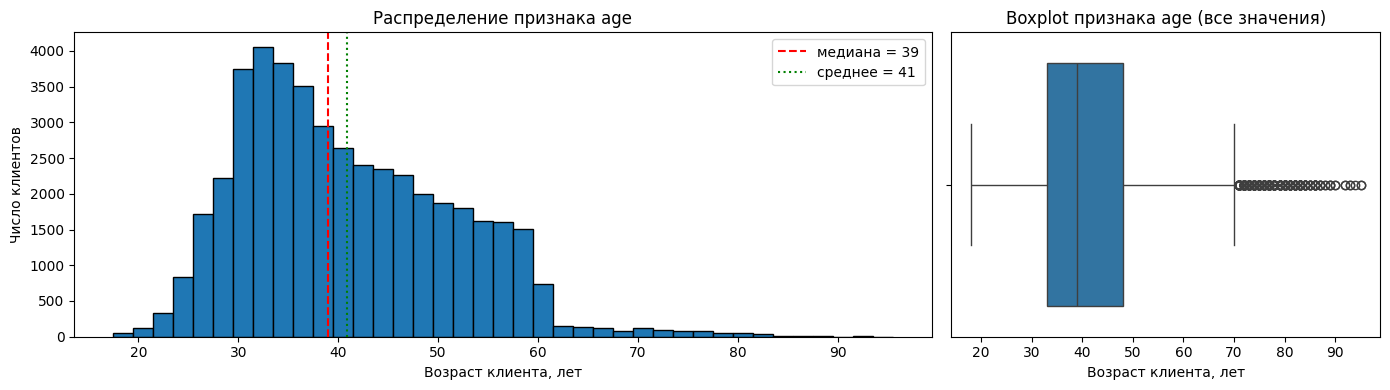

min = 18 | Q1 = 33 | медиана = 39 | Q3 = 48 | max = 95
среднее = 40.9 | skew = 0.68
выбросов по правилу 1.5·IQR: 1.1% (границы: 10 … 70)


In [11]:
# Границы бинов выровнены по целым годам: каждый бин содержит ровно 2 значения возраста.
# При равномерном разбиении диапазона 18–95 на 40 бинов часть бинов охватывала один год,
# часть — два, что создавало ложные провалы на гистограмме.
describe_numeric(df["age"], "age", "Возраст клиента, лет", bins=np.arange(17.5, 96.5, 2))

**Вывод по признаку `age` (возраст клиента, лет).**

1. **Диапазон и центр распределения.** Возраст клиентов находится в диапазоне от 18 до 95 лет. Медиана составляет 39 лет; 50% клиентов находятся в интервале 33–48 лет (Q1–Q3). Наиболее многочисленная возрастная группа — 32–33 года (около 4 000 клиентов). Основная аудитория кампании — клиенты трудоспособного возраста.

2. **Форма распределения.** Распределение умеренно скошено вправо (skew = 0.68): среднее значение (40.9) превышает медиану (39) за счёт хвоста старших возрастов. В диапазоне 60–62 лет наблюдается резкое снижение численности: около 1 500 клиентов в группе 58–59 лет против около 150 в группе 62–63 лет, т. е. примерно в 10 раз. Возможное объяснение — меньшая доля клиентов пенсионного возраста в клиентской базе банка или в списках обзвона. Проверить данную гипотезу на имеющихся данных невозможно.

3. **Выбросы.** По правилу 1.5·IQR выбросами формально являются значения старше 70 лет — 1.1% клиентов. Данные значения не являются ошибками: возраст 70–95 лет правдоподобен для клиента банка, хвост распределения убывает плавно, изолированные аномальные значения отсутствуют. **Решение:** значения сохраняются без изменений. Их удаление исключило бы из выборки группу пожилых клиентов, для которой модель также должна формировать прогноз.

4. **Следствия для дальнейшей работы.**
   - Пропуски отсутствуют; обработка не требуется.
   - Скошенность умеренная (|skew| < 1), поэтому нелинейное преобразование (логарифмирование) не применяется.
   - Признак будет стандартизирован в пайплайне вместе с остальными числовыми признаками.
   - Клиенты старше 60 лет представлены в данных слабо, поэтому оценки для этой группы (в том числе доли согласившихся в двумерном анализе) будут менее надёжными. Возрастные группы старше 60 лет при необходимости будут укрупняться.

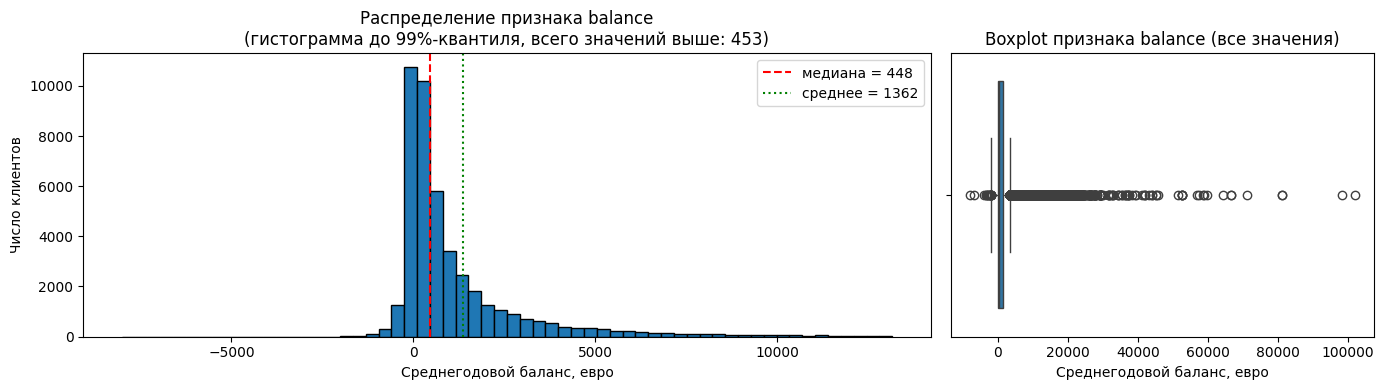

min = -8019 | Q1 = 72 | медиана = 448 | Q3 = 1428 | max = 102127
среднее = 1362.3 | skew = 8.36
выбросов по правилу 1.5·IQR: 10.5% (границы: -1962 … 3462)


In [12]:
describe_numeric(df["balance"], "balance", "Среднегодовой баланс, евро", bins=60, clip_q=0.99)

In [ ]:
print(f"Отрицательный баланс: {(df['balance'] < 0).sum()} клиентов ({(df['balance'] < 0).mean() * 100:.1f}%)")
print(f"Нулевой баланс:       {(df['balance'] == 0).sum()} клиентов ({(df['balance'] == 0).mean() * 100:.1f}%)")
print(f"Положительный баланс: {(df['balance'] > 0).sum()} клиентов ({(df['balance'] > 0).mean() * 100:.1f}%)")

Отрицательный баланс: 3766 клиентов (8.3%)
Нулевой баланс:       3514 клиентов (7.8%)
Положительный баланс: 37931 клиентов (83.9%)


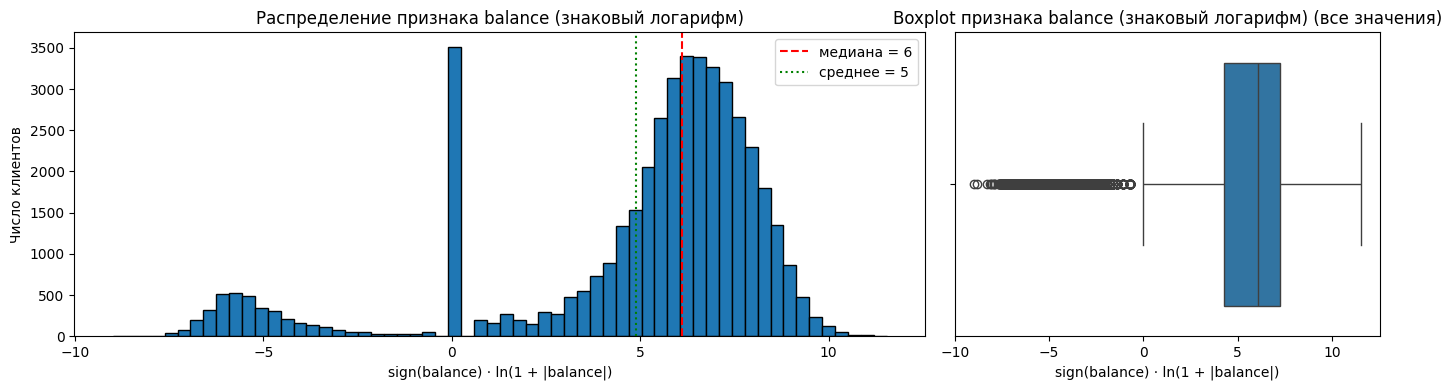

min = -9 | Q1 = 4 | медиана = 6 | Q3 = 7 | max = 12
среднее = 4.9 | skew = -1.58
выбросов по правилу 1.5·IQR: 8.3% (границы: -0 … 12)


In [13]:
# Знаковый логарифм: sign(x)·ln(1 + |x|).
# Обычный логарифм неприменим: у 8.3% клиентов баланс отрицательный, у 7.8% — нулевой.
# Преобразование сохраняет порядок значений и знак, переводит 0 в 0 и сжимает длинный правый хвост.
balance_slog = np.sign(df["balance"]) * np.log1p(df["balance"].abs())

describe_numeric(balance_slog, "balance (знаковый логарифм)",
                 "sign(balance) · ln(1 + |balance|)", bins=60)

**Вывод по признаку `balance` (среднегодовой баланс на счёте, евро).**

1. **Диапазон и центр распределения.** Значения находятся в диапазоне от −8 019 до 102 127 евро. Медиана составляет 448 евро; 50% клиентов находятся в интервале 72–1 428 евро (Q1–Q3).

2. **Форма распределения.** Распределение исходного признака сильно скошено вправо (skew = 8.36): среднее значение (1 362 евро) втрое превышает медиану. Основная масса клиентов имеет баланс до нескольких тысяч евро, при этом правый хвост тянется до 102 127 евро. На гистограмме без ограничения диапазона вся основная масса значений сжимается в один столбец, поэтому гистограмма построена по 99% значений (453 наибольших значения не отображены; на boxplot они показаны).

3. **Отрицательные и нулевые значения.** У 3 766 клиентов (8.3%) баланс отрицательный, у 3 514 (7.8%) — нулевой. Отрицательный среднегодовой баланс соответствует использованию овердрафта или задолженности перед банком и является допустимым значением, а не ошибкой данных.

4. **Выбросы.** По правилу 1.5·IQR выбросами формально являются 10.5% значений исходного признака. Столь высокая доля означает, что правило неприменимо к данному распределению: оно рассчитано на распределения, близкие к симметричным, и на сильно скошенных данных относит к выбросам весь правый хвост. Значения до 102 127 евро и до −8 019 евро правдоподобны для банковских счетов и изолированных аномалий не образуют. **Решение:** значения сохраняются без изменений; влияние хвоста снижается преобразованием признака (п. 5).

5. **Преобразование.** Применено знаковое логарифмическое преобразование f(x) = sign(x)·ln(1 + |x|). Обычный логарифм неприменим из-за нулевых и отрицательных значений. Преобразование сохраняет порядок и знак значений, переводит 0 в 0 и сжимает правый хвост. После преобразования распределение положительных значений близко к симметричному. В преобразованном признаке отчётливо выделяются три группы клиентов: с отрицательным, нулевым и положительным балансом. Коэффициент асимметрии всего распределения (−1.58) и доля выбросов по правилу 1.5·IQR (8.3%, что совпадает с долей клиентов с отрицательным балансом) отражают наличие этих групп, а не длинный хвост. Поэтому данные показатели не используются как аргумент против преобразования.

6. **Следствия для дальнейшей работы.**
   - Пропуски отсутствуют.
   - В пайплайне к признаку применяется знаковый логарифм, затем стандартизация.
   - Поскольку отрицательный и нулевой баланс являются качественно различными состояниями, которые один числовой признак описывает плохо, в разделе «Конструирование признаков» будут добавлены бинарные признаки `balance_negative` и `balance_zero`.

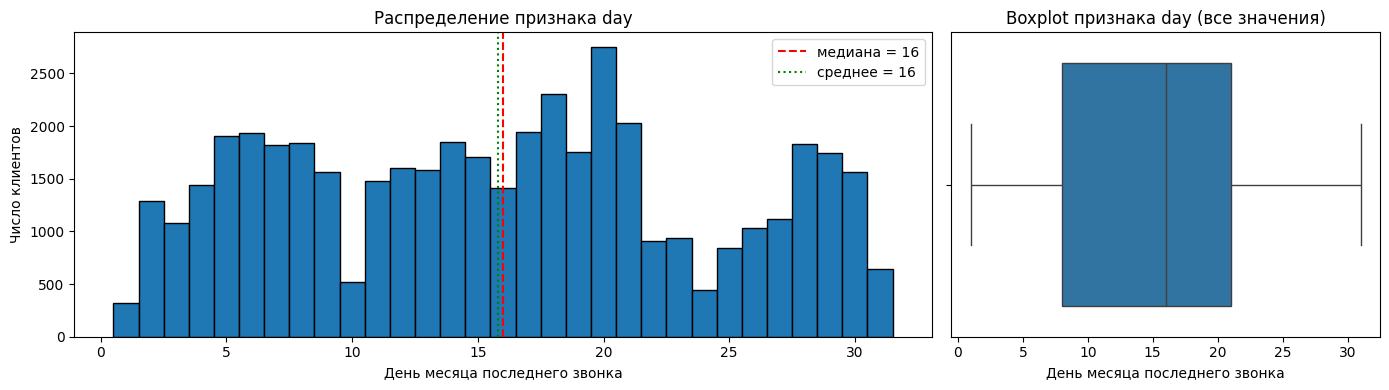

min = 1 | Q1 = 8 | медиана = 16 | Q3 = 21 | max = 31
среднее = 15.8 | skew = 0.09
выбросов по правилу 1.5·IQR: 0.0% (границы: -12 … 40)


In [14]:
# Один бин на каждый день месяца; границы на полуцелых значениях (0.5, 1.5, …, 31.5)
describe_numeric(df["day"], "day", "День месяца последнего звонка", bins=np.arange(0.5, 32.5, 1))

**Вывод по признаку `day` (день месяца последнего звонка).**

1. **Корректность данных.** Значения находятся в допустимом диапазоне 1–31; пропуски и выбросы отсутствуют (доля выбросов по правилу 1.5·IQR — 0%).

2. **Форма распределения.** Распределение близко к симметричному (skew = 0.09; среднее 15.8, медиана 16), но не является равномерным: число звонков по дням варьирует от ~320 (1-е число) до ~2 750 (20-е число).

3. **Интерпретация неравномерности.**
   - Малое число звонков 31-го числа (~650) объясняется календарём: 31-е число есть только в 7 из 12 месяцев.
   - Минимум 1-го числа (~320) может быть связан с праздничными днями, приходящимися на 1-е число (1 января, 1 мая, 1 ноября в Португалии), и с началом месяца. Это гипотеза; на имеющихся данных она не проверяется, так как год не указан.
   - Провалы 10-го и 24-го числа и пик 20-го числа по имеющимся данным объяснить нельзя; вероятно, они отражают график работы колл-центра в отдельные периоды кампании.

4. **Природа признака.** Признак характеризует не клиента, а время контакта, которое выбирает банк. Поэтому связь `day` с целевой переменной, если она будет обнаружена, имеет прямое практическое значение: день звонка можно планировать. Связь проверяется в разделе «Двумерный анализ» (гипотеза: согласие выше в дни после выплаты заработной платы).

5. **Следствия для дальнейшей работы.** Признак является циклическим: 31-е и 1-е число — соседние дни, однако в числовом представлении максимально удалены друг от друга. Для корректного учёта этой близости в пайплайне будет применено циклическое кодирование (синус и косинус дня месяца).

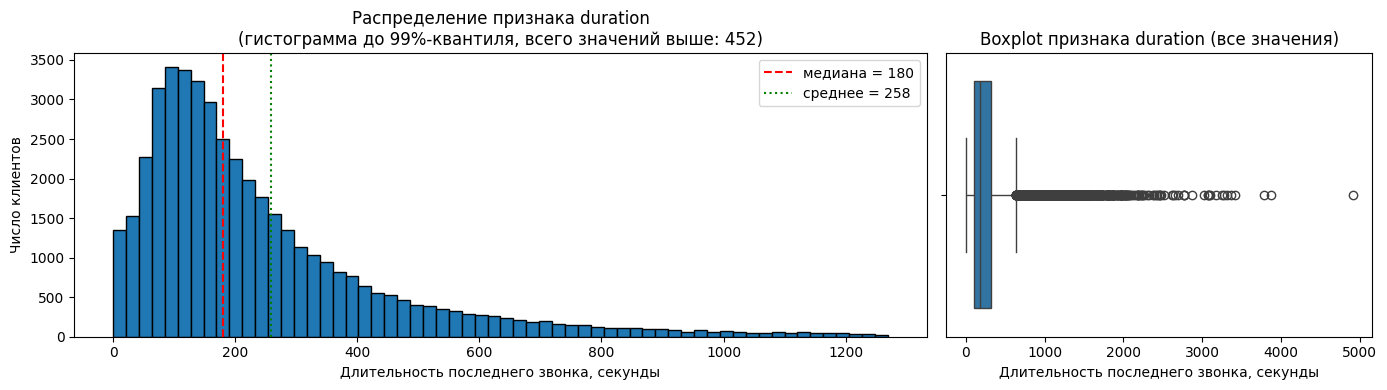

min = 0 | Q1 = 103 | медиана = 180 | Q3 = 319 | max = 4918
среднее = 258.2 | skew = 3.14
выбросов по правилу 1.5·IQR: 7.2% (границы: -221 … 643)


In [15]:
describe_numeric(df["duration"], "duration", "Длительность последнего звонка, секунды", bins=60, clip_q=0.99)

In [16]:
zero = df["duration"] == 0
short = df["duration"] < 10

print(f"Звонков длительностью 0 с:  {zero.sum()}, из них согласились: {df.loc[zero, 'y'].sum()}")
print(f"Звонков короче 10 с:        {short.sum()}, из них согласились: {df.loc[short, 'y'].sum()}")
print(f"Доля согласившихся среди звонков короче 10 с: {df.loc[short, 'y'].mean() * 100:.1f}%")
print(f"Доля согласившихся в целом:                   {df['y'].mean() * 100:.1f}%")

Звонков длительностью 0 с:  3, из них согласились: 0
Звонков короче 10 с:        342, из них согласились: 1
Доля согласившихся среди звонков короче 10 с: 0.3%
Доля согласившихся в целом:                   11.7%


**Вывод по признаку `duration` (длительность последнего звонка, секунды).**

1. **Диапазон и центр распределения.** Значения находятся в диапазоне от 0 до 4 918 секунд (около 82 минут). Медиана составляет 180 секунд (3 минуты); 50% звонков длятся от 103 до 319 секунд (Q1–Q3).

2. **Форма распределения.** Распределение сильно скошено вправо (skew = 3.14): среднее значение (258 с) превышает медиану на 43%. Гистограмма построена по 99% значений (452 наибольших значения не отображены; на boxplot они показаны).

3. **Выбросы.** По правилу 1.5·IQR выбросами формально являются 7.2% звонков — длительностью более 643 секунд (около 11 минут). Данные значения не являются ошибками: разговоры длительностью 10–60 минут правдоподобны для консультации по банковскому продукту; хвост распределения убывает плавно. Максимальное значение (4 918 с) изолировано от остальных, однако также физически возможно. **Решение:** значения сохраняются без изменений.

4. **Нулевые и сверхкороткие звонки.** Зафиксировано 3 звонка длительностью 0 секунд и 342 звонка короче 10 секунд; такие звонки соответствуют несостоявшемуся разговору (клиент не ответил или прервал звонок). Среди звонков короче 10 секунд вклад открыл 1 клиент (0.3%) при средней доле согласившихся 11.7%.

5. **Признак содержит информацию о результате звонка.** Длительность разговора определяется в том числе его исходом: клиент, отказавшийся сразу, завершает разговор быстро, а согласившийся участвует в оформлении. При этом значение `duration` становится известно только после завершения звонка, тогда как решение о звонке банк принимает до него. Это признак утечки целевой переменной; подробное обоснование приводится в разделе «Анализ утечки».

6. **Следствия для дальнейшей работы.** Пропуски отсутствуют. Признак исключается из набора признаков модели (см. раздел «Анализ утечки»), поэтому преобразование к нему не применяется. В двумерном анализе признак рассматривается для иллюстрации силы его связи с целевой переменной.

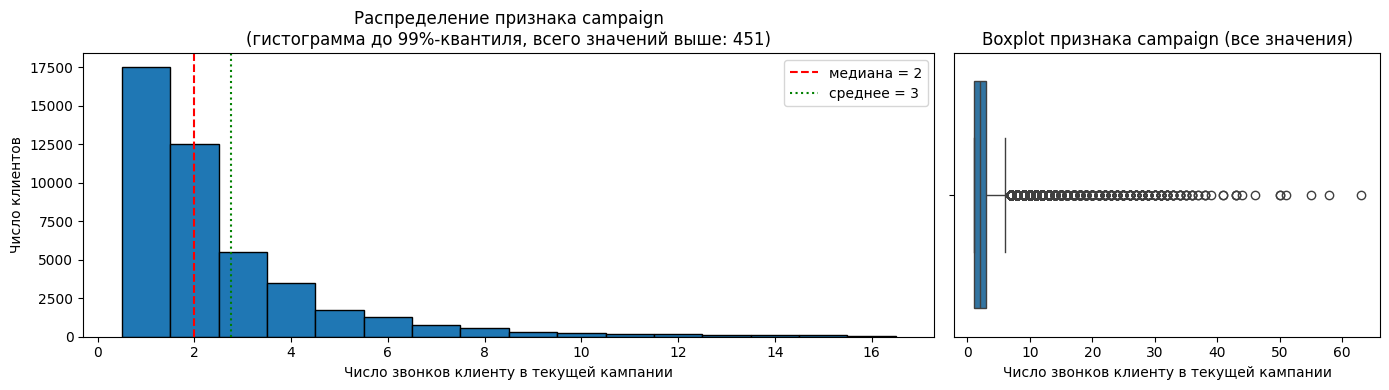

min = 1 | Q1 = 1 | медиана = 2 | Q3 = 3 | max = 63
среднее = 2.8 | skew = 4.90
выбросов по правилу 1.5·IQR: 6.8% (границы: -2 … 6)


In [17]:
# Целочисленный признак: один бин на каждое значение; гистограмма до 99%-квантиля (длинный правый хвост)
q99 = df["campaign"].quantile(0.99)
describe_numeric(df["campaign"], "campaign", "Число звонков клиенту в текущей кампании",
                 bins=np.arange(0.5, q99 + 1.5, 1), clip_q=0.99)

**Вывод по признаку `campaign` (число звонков клиенту в текущей кампании, включая последний).**

1. **Диапазон и центр распределения.** Значения находятся в диапазоне от 1 до 63. Медиана — 2 звонка; 75% клиентов получили не более 3 звонков (Q3). Один звонок получили около 17 500 клиентов (≈39%), два — около 12 500 (≈28%).

2. **Форма распределения.** Распределение сильно скошено вправо (skew = 4.90): частота убывает приблизительно геометрически — каждое следующее значение встречается примерно вдвое реже предыдущего. Гистограмма построена по 99% значений (451 клиент с числом звонков более 16 не отображён; на boxplot показан).

3. **Корректность данных.** Минимальное значение 1 согласуется с определением признака (учитывается последний звонок, поэтому значение не может быть меньше 1).

4. **Выбросы.** По правилу 1.5·IQR выбросами являются значения больше 6 — 6.8% клиентов. Значения до 63 звонков велики, но правдоподобны: при повторных попытках дозвониться в ходе многомесячной кампании число вызовов может накапливаться. Признаков ошибки ввода (невозможных значений, изолированных аномалий) нет. **Решение:** значения сохраняются без изменений; влияние хвоста снижается преобразованием.

5. **Природа признака.** Число звонков определяется действиями банка, поэтому его связь с целевой переменной имеет практическое значение. В разделе «Двумерный анализ» проверяется, повышают ли повторные звонки вероятность согласия.

6. **Следствия для дальнейшей работы.** Пропуски отсутствуют. В пайплайне к признаку применяется преобразование ln(1 + x) (нулевые и отрицательные значения отсутствуют, знаковый вариант не требуется), затем стандартизация.

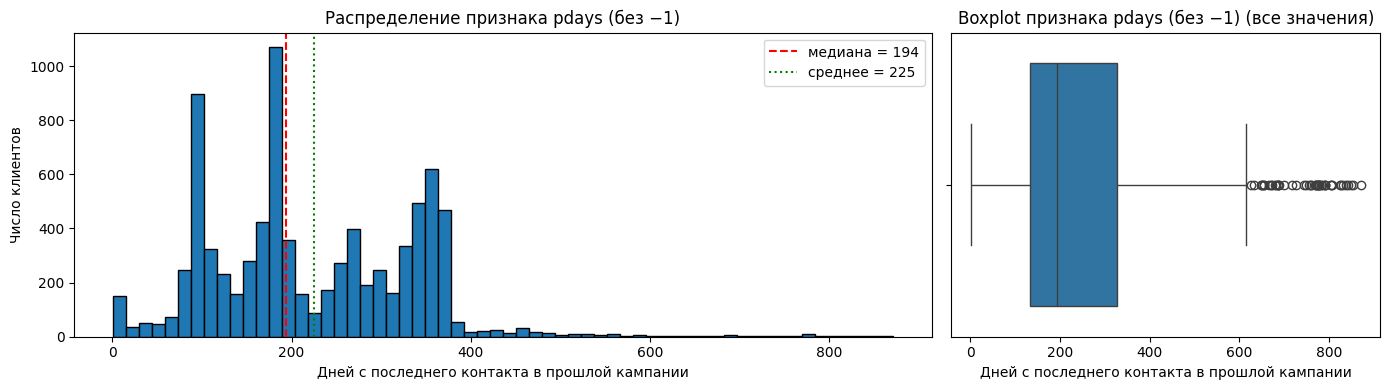

min = 1 | Q1 = 133 | медиана = 194 | Q3 = 327 | max = 871
среднее = 224.6 | skew = 0.69
выбросов по правилу 1.5·IQR: 0.6% (границы: -158 … 618)


In [18]:
# Анализируются только клиенты, с которыми был контакт в прошлой кампании:
# значение -1 означает «контакта не было» и не является числом дней (см. обзор данных)
pdays_real = df.loc[df["pdays"] != -1, "pdays"]
describe_numeric(pdays_real, "pdays (без −1)",
                 "Дней с последнего контакта в прошлой кампании", bins=60)

**Вывод по признаку `pdays` (число дней с последнего контакта в прошлой кампании).**

Анализ проводится только для 8 257 клиентов (18.3%), с которыми был контакт в прошлой кампании. У остальных 36 954 клиентов (81.7%) значение равно −1, что означает отсутствие контакта (см. обзор данных); это значение не является числом дней и из анализа распределения исключено.

1. **Диапазон и центр распределения.** Значения находятся в диапазоне от 1 до 871 дня. Медиана составляет 194 дня; 50% значений находятся в интервале 133–327 дней (Q1–Q3).

2. **Форма распределения.** Распределение многовершинное: выделяются пики в окрестностях ~90–100, ~180–190, ~270 и ~350–370 дней, т. е. с интервалом около 90 дней. Наиболее вероятное объяснение — прошлые кампании проводились волнами с периодичностью около квартала, поэтому значение признака в значительной мере определяется расписанием кампаний банка, а не характеристиками клиента. В силу многовершинности среднее (224.6) и медиана (194) не описывают типичное значение. Коэффициент асимметрии (0.69) соответствует умеренной скошенности вправо.

3. **Выбросы и корректность данных.** По правилу 1.5·IQR выбросами являются значения более 618 дней — 0.6% клиентов с прошлым контактом. Максимальное значение (871 день, около 2.4 года) не превышает продолжительности периода наблюдения (май 2008 — ноябрь 2010, около 900 дней) и является правдоподобным. **Решение:** значения сохраняются без изменений.

4. **Следствия для дальнейшей работы.**
   - Скошенность умеренная, нелинейное преобразование не требуется; признак стандартизируется в пайплайне.
   - Значение −1 необходимо заменить, так как его использование в качестве числа искажает признак (−1 день интерпретировался бы как контакт в недавнем прошлом). Способ замены обосновывается в разделе «Пропуски».
   - Поскольку для 81.7% клиентов признак не определён, в разделе «Конструирование признаков» будет добавлен бинарный признак `was_contacted_before` (был ли контакт в прошлой кампании).

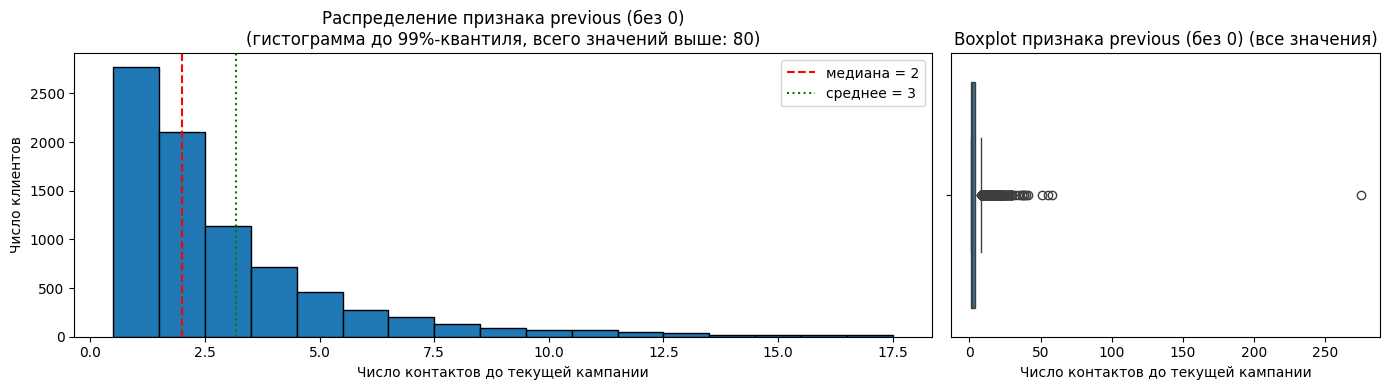

min = 1 | Q1 = 1 | медиана = 2 | Q3 = 4 | max = 275
среднее = 3.2 | skew = 27.64
выбросов по правилу 1.5·IQR: 5.5% (границы: -4 … 8)


In [19]:
# Анализируются только клиенты с контактом в прошлой кампании (previous > 0);
# previous = 0 у тех же 36 954 клиентов, у которых pdays = -1 (см. обзор данных)
prev_real = df.loc[df["previous"] > 0, "previous"]
q99 = prev_real.quantile(0.99)
describe_numeric(prev_real, "previous (без 0)", "Число контактов до текущей кампании",
                 bins=np.arange(0.5, q99 + 1.5, 1), clip_q=0.99)

In [20]:
print("5 наибольших значений previous:", prev_real.nlargest(5).tolist())
print(f"skew со всеми значениями:           {prev_real.skew():.2f}")
print(f"skew без максимального значения:    {prev_real[prev_real < prev_real.max()].skew():.2f}")
print(f"ln(1 + x) для максимума и следующего значения: "
      f"{np.log1p(prev_real.max()):.2f} и {np.log1p(prev_real.nlargest(2).iloc[1]):.2f}")

5 наибольших значений previous: [275, 58, 55, 51, 41]
skew со всеми значениями:           27.64
skew без максимального значения:    4.66
ln(1 + x) для максимума и следующего значения: 5.62 и 4.08


**Вывод по признаку `previous` (число контактов с клиентом до текущей кампании).**

Анализ проводится только для 8 257 клиентов с контактом в прошлой кампании (`previous > 0`). У остальных 36 954 клиентов значение равно 0; это те же клиенты, у которых `pdays = −1` (см. обзор данных).

1. **Диапазон и центр распределения.** Значения находятся в диапазоне от 1 до 275. Медиана — 2 контакта; 75% клиентов имели не более 4 контактов (Q3).

2. **Форма распределения.** Частота убывает приблизительно геометрически, аналогично признаку `campaign`. Распределение сильно скошено вправо (skew = 27.64). Гистограмма построена по 99% значений (80 наибольших значений не отображены; на boxplot показаны).

3. **Аномальное значение.** Максимальное значение (275) почти в 5 раз превышает следующее по величине (58); последующие значения (58, 55, 51, 41) убывают плавно. Исключение одного этого значения снижает коэффициент асимметрии с 27.64 до 4.66, т. е. форму распределения в значительной мере определяет одно наблюдение из 8 257. Значение 275 соответствует контакту в среднем каждые 3 дня на протяжении всего периода наблюдения (около 900 дней), что неправдоподобно для маркетингового обзвона. Значение классифицировано как **вероятная ошибка данных**.

4. **Решение по аномальному значению.** Рассмотрены три варианта:
   - удаление строки — отклонено: остальные признаки клиента корректны и были бы потеряны;
   - замена значения — отклонена: истинное значение неизвестно, любая замена была бы произвольной;
   - **сохранение значения с логарифмическим преобразованием — принято.** Преобразование ln(1 + x) требуется признаку независимо от аномалии (без неё skew = 4.66). После преобразования аномальное значение (5.62) отстоит от следующего (4.08) незначительно и не оказывает доминирующего влияния на модель.

   Прочие значения за пределами 1.5·IQR (более 8 контактов, 5.5% клиентов с прошлым контактом) правдоподобны и сохраняются без изменений.

5. **Следствия для дальнейшей работы.** В пайплайне к признаку применяется ln(1 + x); значение 0 (отсутствие прошлого контакта) переходит в 0 и является корректным числом контактов. Затем признак стандартизируется. Признак информационно пересекается с `pdays` и планируемым признаком `was_contacted_before`; степень их взаимосвязи будет оценена по матрице корреляций.

In [21]:
def describe_categorical(col, title, order=None, rare_threshold=1.0):
    """Диаграмма частот категориального признака с долями; пропуски показаны отдельной категорией.

    col            — имя столбца
    title          — описание признака для заголовка
    order          — порядок категорий на графике (например, календарный для месяцев);
                     по умолчанию — по убыванию частоты
    rare_threshold — порог доли (в %), ниже которого категория считается редкой
    """
    counts = df[col].value_counts(dropna=False)          # dropna=False — пропуски тоже считаются
    if order is not None:
        counts = counts.reindex(order)
    share = counts / len(df) * 100
    labels = ["пропуск" if pd.isna(c) else str(c) for c in counts.index]

    fig, ax = plt.subplots(figsize=(10, max(3, 0.45 * len(counts))))
    ax.barh(labels, counts.values, edgecolor="black")
    ax.invert_yaxis()                                     # первая категория — сверху
    for i, (c, s) in enumerate(zip(counts.values, share.values)):
        ax.text(c, i, f"  {c} ({s:.1f}%)", va="center")   # подпись числа и доли у каждого столбца
    ax.set_xlim(0, counts.max() * 1.25)                   # место справа для подписей
    ax.set_title(f"Частоты признака {col}: {title}")
    ax.set_xlabel("Число клиентов")
    ax.set_ylabel("Категория")
    fig.tight_layout()
    plt.show()

    real = share[[not pd.isna(c) for c in share.index]]
    print(f"Категорий (без учёта пропуска): {len(real)}")
    print(f"Редких категорий (доля < {rare_threshold}%): {(real < rare_threshold).sum()}"
          + (f" — {', '.join(map(str, real[real < rare_threshold].index))}" if (real < rare_threshold).any() else ""))

### 3.2. Категориальные признаки

Для каждого категориального признака строится диаграмма частот; пропуски показаны отдельной категорией. Категория считается **редкой**, если её доля составляет менее 1% объектов (менее ~450 клиентов): при такой численности оценка связи категории с целевой переменной ненадёжна.

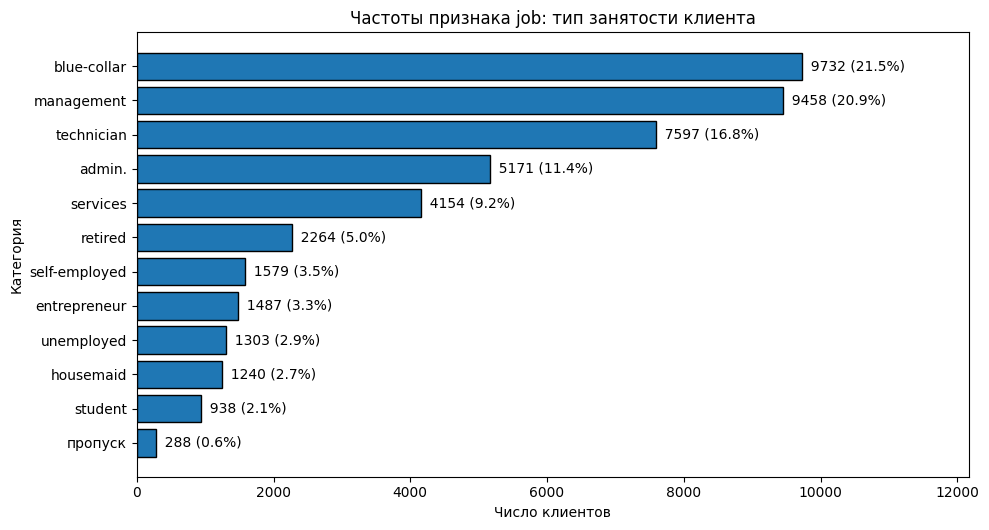

Категорий (без учёта пропуска): 11
Редких категорий (доля < 1.0%): 0


In [22]:
describe_categorical("job", "тип занятости клиента")

**Вывод по признаку `job` (тип занятости клиента).**

1. **Структура.** Признак содержит 11 категорий. Три наиболее частые — `blue-collar` (21.5%), `management` (20.9%) и `technician` (16.8%) — в совокупности составляют 59.2% клиентов. Наименее представлены `student` (2.1%), `housemaid` (2.7%) и `unemployed` (2.9%).

2. **Редкие категории.** Категорий с долей менее 1% нет: наименьшая категория (`student`) насчитывает 938 клиентов, что достаточно для оценки её связи с целевой переменной. Объединение категорий не требуется.

3. **Пропуски.** Значение отсутствует у 288 клиентов (0.6%). Причина и способ заполнения обосновываются в разделе «Пропуски».

4. **Следствия для дальнейшей работы.** Категории не имеют естественного порядка, поэтому признак кодируется методом one-hot encoding. Категории `retired` и `student` характеризуют клиентов с отличающимся от остальных финансовым положением и жизненной ситуацией; их связь с согласием на вклад проверяется в разделе «Двумерный анализ».

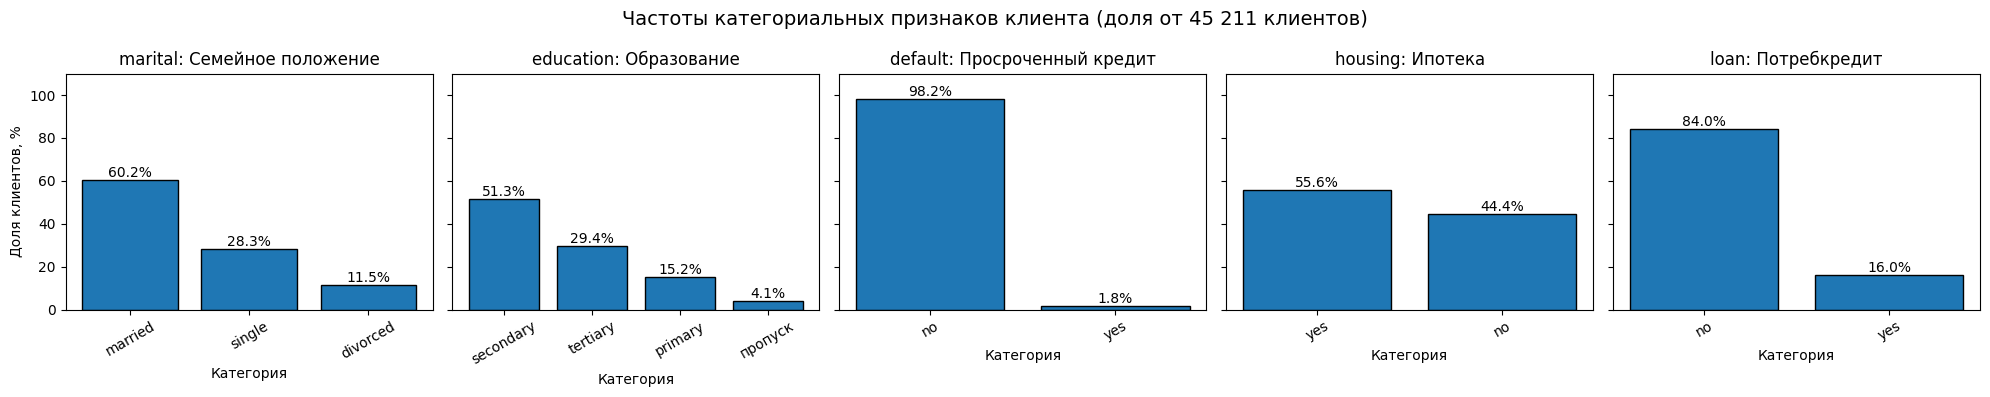

In [23]:
def plot_cat_group(cols, titles, suptitle):
    """Частоты нескольких категориальных признаков на одном рисунке (доли, общая ось Y)."""
    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, col, title in zip(axes, cols, titles):
        counts = df[col].value_counts(dropna=False)
        labels = ["пропуск" if pd.isna(c) else str(c) for c in counts.index]
        share = counts / len(df) * 100
        ax.bar(labels, share.values, edgecolor="black")
        for i, s in enumerate(share.values):
            ax.text(i, s, f"{s:.1f}%", ha="center", va="bottom")
        ax.set_title(f"{col}: {title}")
        ax.set_xlabel("Категория")
        ax.tick_params(axis="x", rotation=30)
    axes[0].set_ylabel("Доля клиентов, %")
    axes[0].set_ylim(0, 110)            # запас сверху, чтобы подписи не наезжали на заголовок
    fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_cat_group(["marital", "education", "default", "housing", "loan"],
               ["Семейное положение", "Образование", "Просроченный кредит", "Ипотека", "Потребкредит"],
               "Частоты категориальных признаков клиента (доля от 45 211 клиентов)")

**Вывод по признакам `marital`, `education`, `default`, `housing`, `loan`.**

1. **`marital` (семейное положение).** Три категории: `married` — 60.2%, `single` — 28.3%, `divorced` (включая вдовых) — 11.5%. Редких категорий и пропусков нет. Категории не упорядочены; кодирование — one-hot.

2. **`education` (образование).** Три категории: `secondary` — 51.3%, `tertiary` — 29.4%, `primary` — 15.2%; пропуски — 4.1%. Редких категорий нет. В отличие от прочих категориальных признаков, категории имеют естественный порядок (primary < secondary < tertiary). Тем не менее используется one-hot кодирование: порядковое кодирование предполагало бы равный «шаг» между уровнями образования, что не обосновано. Причина пропусков и способ их заполнения рассматриваются в разделе «Пропуски».

3. **`default` (наличие просроченного кредита).** Признак крайне несбалансирован: `yes` — 1.8% (около 815 клиентов), `no` — 98.2%. Формально категория `yes` не является редкой (доля выше порога 1%), однако почти постоянный признак несёт мало информации для модели. Признак сохраняется; его полезность оценивается в разделе «Двумерный анализ».

4. **`housing` (наличие ипотеки).** Признак сбалансирован: `yes` — 55.6%, `no` — 44.4%.

5. **`loan` (наличие потребительского кредита).** `no` — 84.0%, `yes` — 16.0%.

6. **Следствия для дальнейшей работы.** Бинарные признаки `default`, `housing`, `loan` кодируются как 0/1. Признаки `housing`, `loan` и `default` характеризуют кредитную нагрузку клиента; в разделе «Двумерный анализ» проверяется гипотеза о том, что клиенты с кредитными обязательствами реже открывают вклад.

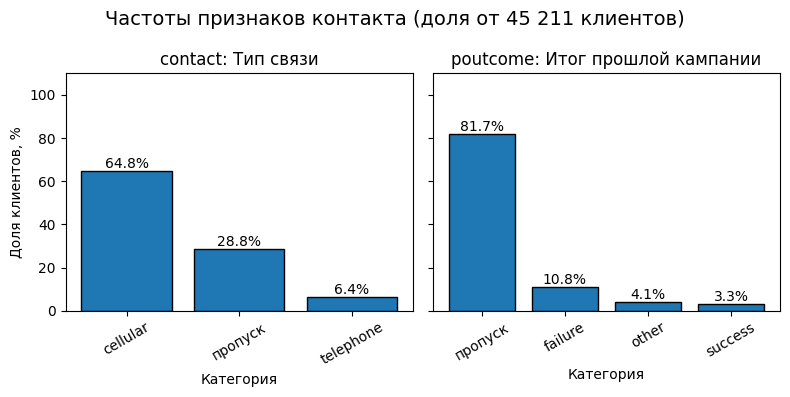

In [24]:
plot_cat_group(["contact", "poutcome"],
               ["Тип связи", "Итог прошлой кампании"],
               "Частоты признаков контакта (доля от 45 211 клиентов)")

**Вывод по признакам `contact` и `poutcome`.**

1. **`contact` (тип связи при последнем звонке).** `cellular` (мобильная связь) — 64.8%, `telephone` (стационарная) — 6.4%; пропуски — 28.8%. Редких категорий нет. Пропуски составляют почти треть объектов, поэтому выбор способа их обработки существенно влияет на признак; он обосновывается в разделе «Пропуски» (гипотеза, сформулированная в обзоре данных: тип связи не фиксировался в начальный период кампании).

2. **`poutcome` (итог прошлой кампании).** Пропуски — 81.7%; как установлено в обзоре данных, практически все они (36 954 из 36 959) соответствуют клиентам, с которыми в прошлой кампании не было контакта, т. е. являются структурными. Среди 18.3% клиентов с прошлым контактом распределение итогов следующее: `failure` — 10.8% от всех клиентов, `other` — 4.1%, `success` — 3.3%. Таким образом, прошлая кампания завершилась успехом примерно у каждого шестого клиента, с которым был контакт (3.3 / 18.3 ≈ 18%). Значение категории `other` в описании датасета не раскрыто.

3. **Редкие категории.** Категорий с долей менее 1% нет; наименьшая категория (`success`, 3.3%, около 1 500 клиентов) достаточна для оценки её связи с целевой переменной.

4. **Отсутствие утечки в `poutcome`.** Признак описывает результат предыдущей кампании, завершившейся до текущего звонка, и, следовательно, известен на момент принятия решения о звонке. Утечки целевой переменной он не содержит.

5. **Следствия для дальнейшей работы.** Оба признака кодируются методом one-hot. Для `poutcome` структурный пропуск будет заменён отдельной категорией, обозначающей отсутствие прошлой кампании (обоснование — в разделе «Пропуски»). В разделе «Двумерный анализ» проверяется гипотеза о том, что клиенты, согласившиеся в прошлой кампании (`success`), значительно чаще соглашаются и в текущей.

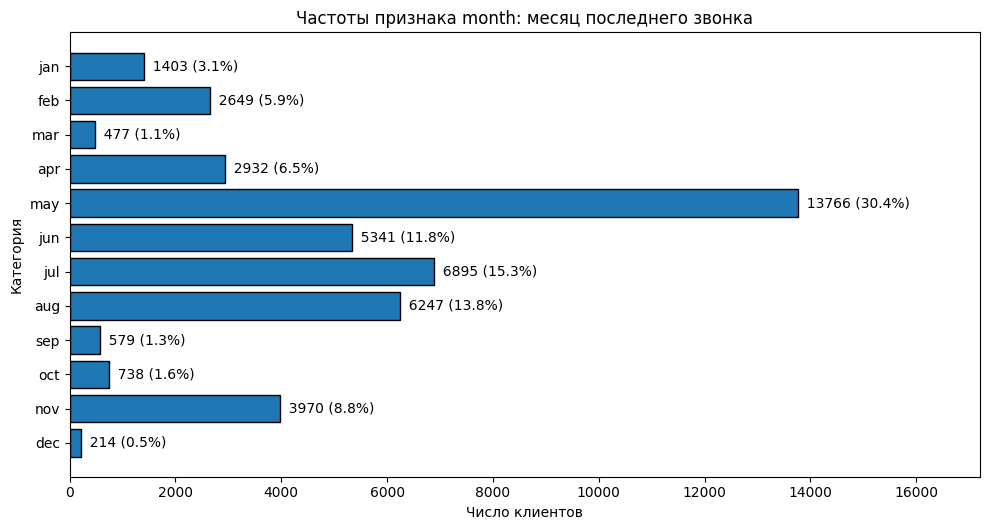

Категорий (без учёта пропуска): 12
Редких категорий (доля < 1.0%): 1 — dec


In [25]:
month_order = ["jan", "feb", "mar", "apr", "may", "jun",
               "jul", "aug", "sep", "oct", "nov", "dec"]
describe_categorical("month", "месяц последнего звонка", order=month_order)

**Вывод по признаку `month` (месяц последнего звонка).**

1. **Структура.** Признак содержит 12 категорий; пропуски отсутствуют. Распределение звонков по месяцам крайне неравномерно: на май приходится 30.4% всех звонков (13 766), на период май–август — 71.3%. Наименьшая активность — в декабре (0.5%), марте (1.1%), сентябре (1.3%) и октябре (1.6%).

2. **Интерпретация.** Неравномерность отражает организацию кампании банком, а не поведение клиентов: интенсивность обзвона определялась банком. Данные объединяют около 2.5 лет (май 2008 — ноябрь 2010) без указания года, поэтому одноимённые месяцы разных лет сливаются в одну категорию. Преобладание мая может быть связано с тем, что наблюдения начинаются в мае 2008 г. и первый этап кампании был наиболее интенсивным; проверить данную гипотезу без указания года невозможно.

3. **Редкие категории.** Декабрь (214 клиентов, 0.5%) является редкой категорией по принятому порогу 1%. Март, сентябрь и октябрь находятся вблизи порога. Оценки доли согласившихся для этих месяцев в разделе «Двумерный анализ» будут менее надёжными из-за малого числа наблюдений.

4. **Следствия для дальнейшей работы.** Месяц является циклическим признаком (декабрь и январь — соседние месяцы). Признак кодируется циклически (синус и косинус номера месяца), аналогично признаку `day`. При таком кодировании каждый месяц представлен точкой на окружности, а не отдельной категорией, поэтому проблема редкой категории `dec` не требует объединения категорий: оценка для декабря опирается на близость к соседним месяцам.

### 3.3. Итоги одномерного анализа

| Признак | Скошенность / структура | Выбросы | Решение для предобработки |
|---|---|---|---|
| `age` | умеренная вправо (skew = 0.68) | >70 лет, 1.1% — реальные | стандартизация |
| `balance` | сильная вправо (skew = 8.36); 8.3% отрицательных, 7.8% нулевых | длинный хвост, реальные значения | sign(x)·ln(1 + \|x\|), стандартизация; новые признаки `balance_negative`, `balance_zero` |
| `day` | близка к симметричной (skew = 0.09), неравномерна по дням | нет | циклическое кодирование |
| `duration` | сильная вправо (skew = 3.14) | длинный хвост, реальные значения | **исключается** (утечка) |
| `campaign` | сильная вправо (skew = 4.90) | до 63 звонков — реальные | ln(1 + x), стандартизация |
| `pdays` | многовершинная (волны кампаний ~каждые 90 дней); 81.7% значений = −1 | 0.6% — реальные | замена −1 (см. «Пропуски»), стандартизация; новый признак `was_contacted_before` |
| `previous` | сильная вправо (skew = 27.64, без аномалии — 4.66) | 275 — вероятная ошибка, сохраняется | ln(1 + x), стандартизация |
| `job` | 11 категорий, редких нет | — | one-hot; пропуски 0.6% |
| `marital` | 3 категории, редких нет | — | one-hot |
| `education` | 3 категории, редких нет | — | one-hot; пропуски 4.1% |
| `default` | 98.2% `no` — почти постоянный | — | 0/1 |
| `housing`, `loan` | бинарные | — | 0/1 |
| `contact` | 2 категории | — | one-hot; пропуски 28.8% |
| `poutcome` | 3 категории + 81.7% структурных пропусков | — | one-hot; пропуск → отдельная категория |
| `month` | сильно неравномерно (май — 30.4%); `dec` редкая (0.5%) | — | циклическое кодирование |

**Основные выводы раздела:**
- Три числовых признака (`balance`, `campaign`, `previous`) сильно скошены и требуют логарифмического преобразования.
- Правило 1.5·IQR неприменимо к сильно скошенным и многовершинным распределениям. Решения о выбросах принимались на основе правдоподобия значений, а не доли точек за пределами правила.
- Выявлено одно значение, классифицированное как вероятная ошибка (`previous` = 275); его влияние нейтрализуется преобразованием.
- Признаки `day`, `month`, `campaign` определяются действиями банка, а не характеристиками клиента; их связь с целевой переменной имеет прямую практическую ценность.
- Признак `duration` содержит информацию о результате звонка и исключается из модели.

## 4. Двумерный анализ

**Цель раздела:** оценить связь признаков с целевой переменной и проверить гипотезы, сформулированные в одномерном анализе.

**Методика.** Для каждого признака клиенты разбиваются на группы (категории признака либо интервалы числового признака), и в каждой группе рассчитывается доля согласившихся открыть вклад. Для каждой группы указывается её численность n и 95%-ный доверительный интервал доли (нормальное приближение: p ± 1.96·√(p(1−p)/n)). Горизонтальная линия — доля согласившихся по всей выборке (11.7%). Различие между группами считается существенным, если их доверительные интервалы не пересекаются.

In [26]:
overall_rate = df["y"].mean() * 100


def target_rate(groups, title, xlabel, sort_by_rate=False):
    """Доля согласившихся (y = 1) по группам с размером групп и 95%-ным доверительным интервалом.

    groups       — Series с меткой группы для каждого клиента (категория или интервал)
    sort_by_rate — сортировать группы по убыванию доли (для категорий без естественного порядка)
    """
    stats = df.groupby(groups, dropna=False, observed=True)["y"].agg(rate="mean", n="size")
    stats.index = ["пропуск" if pd.isna(i) else str(i) for i in stats.index]
    if sort_by_rate:
        stats = stats.sort_values("rate", ascending=False)

    ci = 1.96 * np.sqrt(stats["rate"] * (1 - stats["rate"]) / stats["n"]) * 100
    stats["rate"] = stats["rate"] * 100
    stats["ci"] = ci

    labels = [f"{g}\n(n={n})" for g, n in zip(stats.index, stats["n"])]
    fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(stats)), 4.5))
    ax.bar(labels, stats["rate"], yerr=ci, capsize=4, edgecolor="black")
    ax.axhline(overall_rate, color="red", linestyle="--",
               label=f"по всей выборке: {overall_rate:.1f}%")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Доля согласившихся, %")
    ax.tick_params(axis="x", labelsize=8)
    ax.legend()
    fig.tight_layout()
    plt.show()

    return stats.round(1)

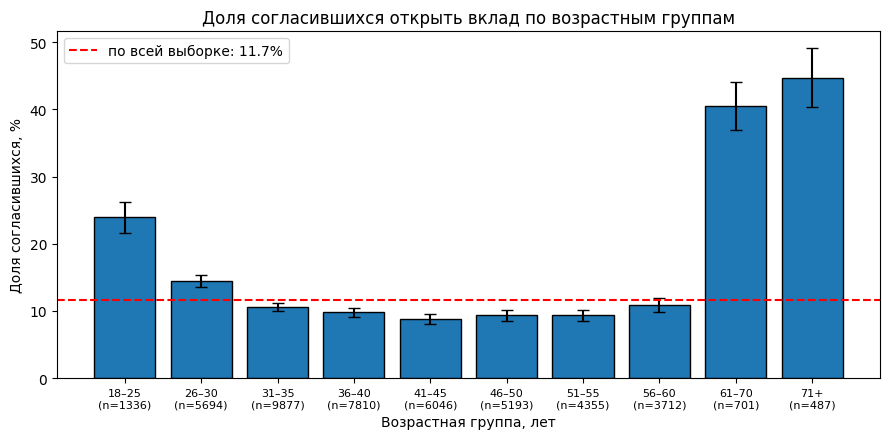

,rate,n,ci
18–25,24.0,1336,2.3
26–30,14.5,5694,0.9
31–35,10.6,9877,0.6
36–40,9.8,7810,0.7
41–45,8.8,6046,0.7
46–50,9.4,5193,0.8
51–55,9.3,4355,0.9
56–60,10.9,3712,1.0
61–70,40.5,701,3.6
71+,44.8,487,4.4


In [27]:
# Возрастные группы по 5 лет; клиенты старше 70 лет объединены в одну группу,
# так как они малочисленны (см. одномерный анализ age)
age_groups = pd.cut(df["age"], bins=[17, 25, 30, 35, 40, 45, 50, 55, 60, 70, 100],
                    labels=["18–25", "26–30", "31–35", "36–40", "41–45",
                            "46–50", "51–55", "56–60", "61–70", "71+"])
target_rate(age_groups, "Доля согласившихся открыть вклад по возрастным группам",
            "Возрастная группа, лет")

**Вывод 1. Связь возраста с согласием немонотонна (U-образна).**

1. **Наблюдение.** Доля согласившихся максимальна у самых молодых и самых старших клиентов и минимальна в среднем возрасте:
   - 18–25 лет — 24.0% ± 2.3%, что в 2 раза выше среднего по выборке (11.7%);
   - 26–30 лет — 14.5% ± 0.9%;
   - 31–60 лет — от 8.8% до 10.9% во всех пятилетних группах, т. е. ниже среднего;
   - 61–70 лет — 40.5% ± 3.6%; старше 70 лет — 44.8% ± 4.4%, что в 3.5–4 раза выше среднего.

2. **Существенность различий.** Переход через 60 лет сопровождается скачком доли согласившихся с 10.9% (56–60 лет) до 40.5% (61–70 лет). Доверительные интервалы этих групп не пересекаются, следовательно, различие не объясняется случайностью выборки. Несмотря на малочисленность групп старше 60 лет (701 и 487 клиентов), их доверительные интервалы достаточно узки для однозначного вывода.

3. **Интерпретация.** Граница резкого роста совпадает с пенсионным возрастом. Возможное объяснение — наличие у пенсионеров и молодых клиентов свободных средств при отсутствии долгосрочных финансовых обязательств (ипотеки, расходов на семью). Гипотеза проверяется при анализе признаков `job` и `housing`.

4. **Практическое значение.** Клиенты старше 60 лет составляют около 2.6% выборки (1 188 из 45 211), однако соглашаются в 4 раза чаще клиентов среднего возраста. В имеющихся данных наиболее восприимчивая группа клиентов охвачена обзвоном в наименьшей степени.

5. **Следствия для модели.** Линейная модель с возрастом в виде одного числового признака способна описать только монотонную зависимость и не воспроизведёт U-образную форму. Для её учёта в разделе «Конструирование признаков» будет добавлен признак, выделяющий возрастные группы с повышенной долей согласия.

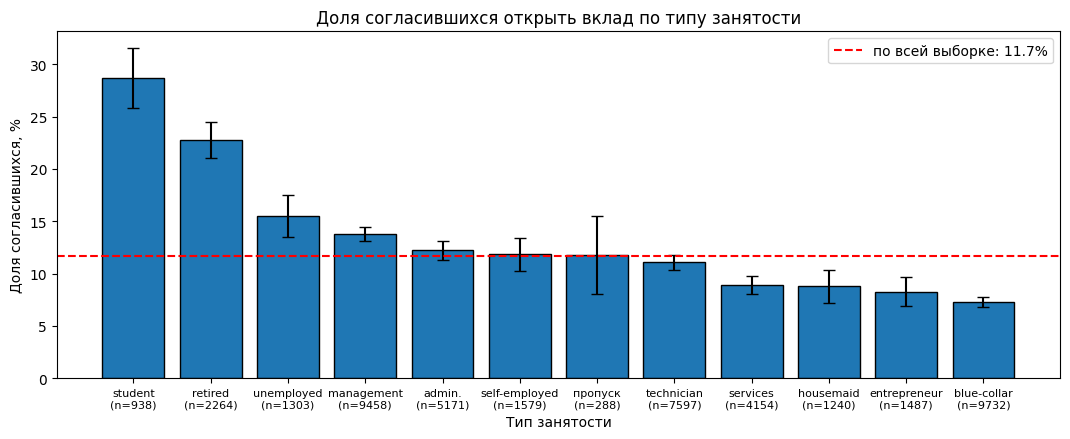

,rate,n,ci
student,28.7,938,2.9
retired,22.8,2264,1.7
unemployed,15.5,1303,2.0
management,13.8,9458,0.7
admin.,12.2,5171,0.9
self-employed,11.8,1579,1.6
пропуск,11.8,288,3.7
technician,11.1,7597,0.7
services,8.9,4154,0.9
housemaid,8.8,1240,1.6


In [28]:
# Категории профессии не упорядочены, поэтому сортируем по убыванию доли согласившихся
target_rate(df["job"], "Доля согласившихся открыть вклад по типу занятости",
            "Тип занятости", sort_by_rate=True)

**Вывод 2. Тип занятости связан с согласием; наиболее восприимчивы студенты и пенсионеры.**

1. **Наблюдение.** Доля согласившихся различается между категориями почти в 4 раза:
   - наибольшая — `student` (28.7% ± 2.9%) и `retired` (22.8% ± 1.7%); доверительные интервалы обеих категорий не пересекаются с интервалами остальных;
   - выше среднего — `unemployed` (15.5% ± 2.0%) и `management` (13.8% ± 0.7%);
   - наименьшая — `blue-collar` (7.3% ± 0.5%), наиболее многочисленная категория (9 732 клиента, 21.5% выборки).

2. **Согласованность с выводом 1.** Высокая доля согласия у студентов и пенсионеров согласуется с повышенной долей в младшей (18–25 лет) и старшей (61+ лет) возрастных группах. Однако доля согласившихся среди пенсионеров (22.8%) существенно ниже, чем среди клиентов старше 60 лет (40.5–44.8%). Следовательно, пенсионный статус и возраст не дублируют друг друга: к категории `retired` относятся и клиенты моложе 60 лет, а эффект возраста не сводится к эффекту занятости. Оба признака несут самостоятельную информацию и сохраняются в модели.

3. **Пропуски.** Доля согласившихся среди клиентов с неизвестным типом занятости (11.8% ± 3.7%, n = 288) не отличается от средней по выборке (11.7%). Отсутствие значения не связано с целевой переменной; это учитывается при выборе способа заполнения в разделе «Пропуски».

4. **Практическое значение.** Категория с наименьшей долей согласия (`blue-collar`) является наиболее многочисленной, а категории с наибольшей долей (`student`, `retired`) — одними из наименее многочисленных (2.1% и 5.0% выборки). Структура обзвона слабо соответствует восприимчивости групп клиентов.

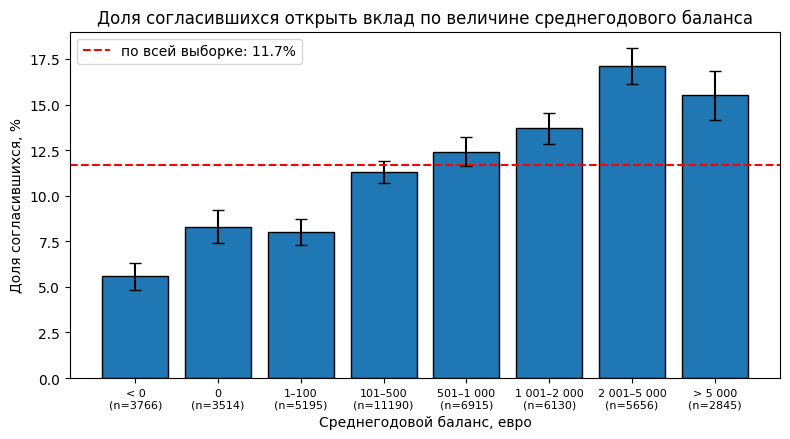

,rate,n,ci
< 0,5.6,3766,0.7
0,8.3,3514,0.9
1–100,8.0,5195,0.7
101–500,11.3,11190,0.6
501–1 000,12.4,6915,0.8
1 001–2 000,13.7,6130,0.9
2 001–5 000,17.1,5656,1.0
> 5 000,15.5,2845,1.3


In [29]:
# Отрицательный и нулевой баланс выделены в отдельные группы (см. одномерный анализ balance);
# положительный баланс разбит на интервалы, расширяющиеся с ростом суммы (из-за сильной скошенности)
balance_groups = pd.cut(df["balance"],
                        bins=[-np.inf, -0.5, 0.5, 100, 500, 1000, 2000, 5000, np.inf],
                        labels=["< 0", "0", "1–100", "101–500", "501–1 000",
                                "1 001–2 000", "2 001–5 000", "> 5 000"])
target_rate(balance_groups, "Доля согласившихся открыть вклад по величине среднегодового баланса",
            "Среднегодовой баланс, евро")

**Вывод 3. Доля согласия растёт с величиной баланса с эффектом насыщения; клиенты с отрицательным балансом соглашаются реже всех.**

1. **Наблюдение.** Доля согласившихся возрастает с ростом среднегодового баланса: от ≈8.0% (баланс 1–100 евро) до ≈17.1% (2 001–5 000 евро), т. е. более чем вдвое. Для баланса свыше 5 000 евро доля (≈15.5%) не превышает долю в группе 2 001–5 000 евро (доверительные интервалы пересекаются): с дальнейшим ростом баланса доля согласия не увеличивается.

2. **Обоснование преобразования признака.** Затухание эффекта с ростом суммы соответствует логарифмической зависимости: изменение баланса на фиксированную величину имеет тем меньшее значение, чем больше исходный баланс. Это подтверждает выбор логарифмического преобразования признака `balance`, сделанный в одномерном анализе на основании формы распределения.

3. **Отрицательный баланс.** У клиентов с отрицательным балансом доля согласившихся минимальна (≈5.6%), и её доверительный интервал не пересекается с интервалом клиентов с нулевым балансом (≈8.3%). Отрицательный баланс характеризует качественно отличающуюся группу клиентов (с долговой нагрузкой), что обосновывает введение бинарного признака `balance_negative`.

4. **Нулевой баланс.** Доля согласившихся при нулевом балансе (≈8.3%) не отличается от доли при балансе 1–100 евро (≈8.0%; интервалы пересекаются). Таким образом, нулевой баланс не выделяется как особая группа по отношению к целевой переменной; полезность признака `balance_zero` будет проверена в разделе «Конструирование признаков».

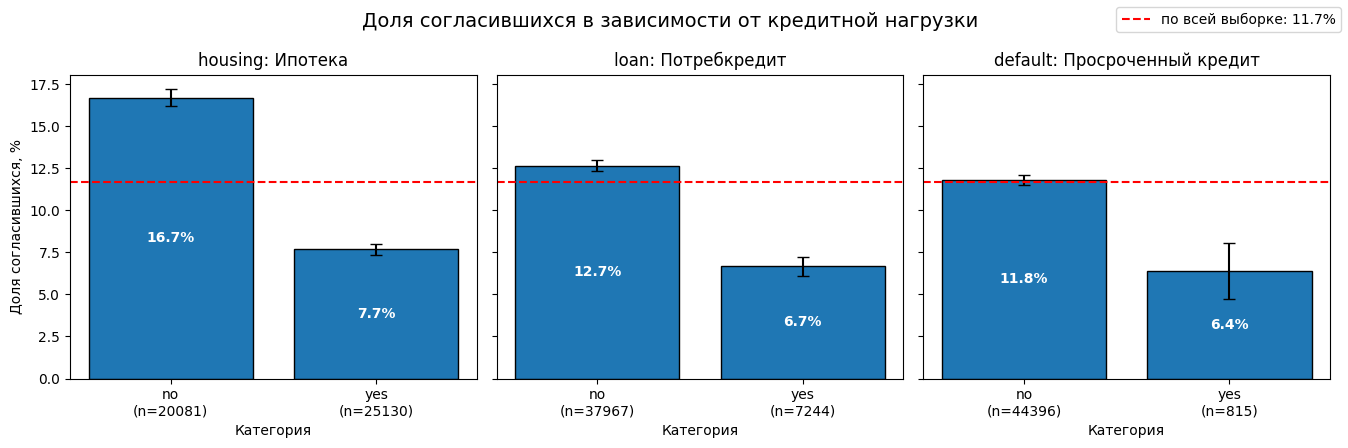

In [30]:
def target_rate_group(cols, titles, suptitle):
    """Доля согласившихся по категориям нескольких признаков на одном рисунке (общая ось Y)."""
    fig, axes = plt.subplots(1, len(cols), figsize=(4.5 * len(cols), 4.5), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, col, title in zip(axes, cols, titles):
        stats = df.groupby(col, dropna=False)["y"].agg(rate="mean", n="size")
        ci = 1.96 * np.sqrt(stats["rate"] * (1 - stats["rate"]) / stats["n"]) * 100
        labels = [f"{'пропуск' if pd.isna(g) else g}\n(n={n})" for g, n in zip(stats.index, stats["n"])]
        ax.bar(labels, stats["rate"] * 100, yerr=ci, capsize=4, edgecolor="black")
        for i, r in enumerate(stats["rate"] * 100):
            ax.text(i, r / 2, f"{r:.1f}%", ha="center", va="center", color="white", fontweight="bold")
        ax.axhline(overall_rate, color="red", linestyle="--")
        ax.set_title(f"{col}: {title}")
        ax.set_xlabel("Категория")
    axes[0].set_ylabel("Доля согласившихся, %")
    fig.legend(["по всей выборке: 11.7%"], loc="upper right")
    fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout()
    plt.show()


target_rate_group(["housing", "loan", "default"],
                  ["Ипотека", "Потребкредит", "Просроченный кредит"],
                  "Доля согласившихся в зависимости от кредитной нагрузки")

**Вывод 4. Наличие кредитных обязательств связано с пониженной долей согласия.**

1. **Наблюдение.** По всем трём признакам кредитной нагрузки клиенты с обязательствами соглашаются открыть вклад реже; доверительные интервалы групп `yes` и `no` не пересекаются ни для одного признака:
   - `housing` (ипотека): 7.7% при наличии против 16.7% при отсутствии — различие в 2.2 раза;
   - `loan` (потребительский кредит): 6.7% против 12.7% — в 1.9 раза;
   - `default` (просроченный кредит): 6.4% против 11.8% — в 1.8 раза.

2. **Сравнение признаков.** Наиболее значим для модели признак `housing`: он сочетает наибольшее различие долей со сбалансированностью групп (55.6% / 44.4%). Признак `default`, напротив, при сопоставимом различии долей затрагивает лишь 1.8% клиентов (815 человек), поэтому его вклад в качество модели ожидается незначительным. Это уточняет вывод одномерного анализа: признак почти постоянен, но связан с целевой переменной и сохраняется.

3. **Интерпретация и ограничения.** Результат согласуется с гипотезой о том, что клиенты с кредитными обязательствами располагают меньшим объёмом свободных средств. Вместе с тем наличие ипотеки связано с возрастом (её чаще имеют клиенты среднего возраста, у которых доля согласия и без того ниже, см. вывод 1). Поэтому наблюдаемая связь не может интерпретироваться как причинная: часть различия может объясняться возрастом клиента. Взаимосвязь признаков между собой учитывается при анализе матрицы корреляций.

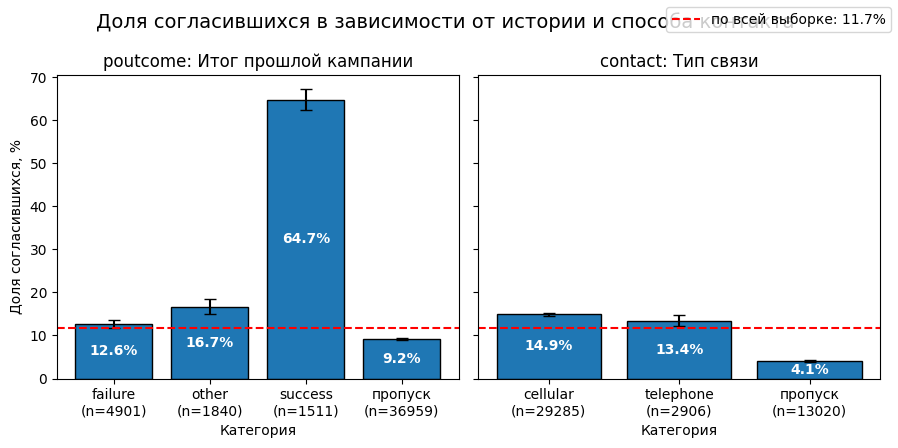

In [31]:
target_rate_group(["poutcome", "contact"],
                  ["Итог прошлой кампании", "Тип связи"],
                  "Доля согласившихся в зависимости от истории и способа контакта")

**Вывод 5. Успех в прошлой кампании — наиболее сильный индикатор согласия; пропуск в `contact` связан с целевой переменной.**

1. **`poutcome`.** Клиенты, открывшие вклад по итогам прошлой кампании (`success`, n = 1 511), соглашаются в текущей кампании в 64.7% случаев, что в 5.5 раза превышает среднюю долю по выборке. Это наиболее сильная связь с целевой переменной среди всех рассмотренных признаков. Доли для остальных итогов прошлой кампании близки к средней (`failure` — 12.6%, `other` — 16.7%). Клиенты без контакта в прошлой кампании (структурный пропуск, n = 36 959) соглашаются реже всех — в 9.2% случаев. Признак описывает события, предшествующие текущему звонку, и утечки не содержит (см. одномерный анализ).

2. **`contact`: тип связи.** Различие долей между мобильной (14.9%) и стационарной (13.4%) связью невелико: сам тип связи слабо связан с согласием.

3. **`contact`: пропуски.** Доля согласившихся среди клиентов с неизвестным типом связи составляет 4.1% (n = 13 020), что в 3.5 раза ниже, чем среди клиентов с известным типом связи; доверительные интервалы не пересекаются. Следовательно, **пропуск в `contact` информативен**: факт отсутствия значения связан с целевой переменной.

4. **Следствия для предобработки.**
   - Заполнение пропусков в `contact` наиболее частым значением (`cellular`) недопустимо: оно объединило бы группы с долей согласия 4.1% и 14.9% и устранило бы выявленную связь. Пропуск сохраняется как отдельная категория.
   - Для `poutcome` структурный пропуск также выделяется в отдельную категорию: группа клиентов без прошлой кампании имеет собственную долю согласия (9.2%), отличную от остальных.
   - Причина связи пропуска в `contact` с целевой переменной исследуется в разделе «Пропуски» (гипотеза: тип связи не фиксировался в начальный период кампании).

### Итоги двумерного анализа

| № | Признак | Характер связи с согласием | Следствие для модели |
|---|---|---|---|
| 1 | `age` | немонотонная (U-образная): максимум у клиентов 18–25 и 61+ лет | добавить признак возрастных групп |
| 2 | `job` | наибольшая доля у `student` и `retired`, наименьшая — у `blue-collar` | one-hot; признак не дублирует `age` |
| 3 | `balance` | рост с насыщением; минимум при отрицательном балансе | подтверждено логарифмическое преобразование; признак `balance_negative` |
| 4 | `housing`, `loan`, `default` | кредитные обязательства связаны с пониженной долей согласия | сохраняются; наиболее значим `housing` |
| 5 | `poutcome`, `contact` | `success` — 64.7% согласия; пропуск в `contact` — 4.1% | пропуски в обоих признаках сохраняются как отдельные категории |

**Основные выводы раздела:**
- Наиболее сильный индикатор согласия — успешный итог прошлой кампании (доля согласия в 5.5 раза выше средней).
- Связь возраста с целевой переменной нелинейна, что требует дополнительного признака для линейной модели.
- Пропуски в `contact` несут информацию о целевой переменной; это определяет стратегию их обработки.
- Установленные связи не интерпретируются как причинные: признаки взаимосвязаны (например, возраст, занятость и наличие ипотеки).

## 5. Матрица корреляций

Для числовых признаков и целевой переменной рассчитан коэффициент ранговой корреляции Спирмена. Выбор обусловлен сильной скошенностью признаков `balance`, `campaign`, `previous` и наличием аномального значения (см. одномерный анализ): коэффициент Пирсона чувствителен к экстремальным значениям, коэффициент Спирмена — нет. Кроме того, коэффициент Спирмена инвариантен к монотонным преобразованиям, поэтому результат одинаков для исходных и логарифмированных признаков.

Значение `pdays = −1` («контакта не было») заменено на пропуск: оно не является числом дней, и его ранжирование как наименьшего значения исказило бы результат. Корреляции с `pdays` рассчитаны по 8 257 клиентам с прошлым контактом.

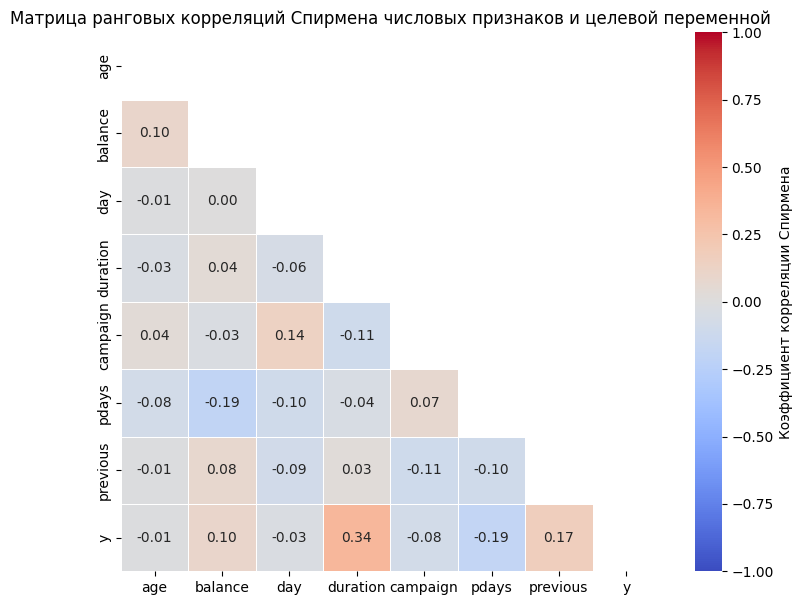

In [32]:
num_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous", "y"]
corr_data = df[num_cols].copy()
corr_data["pdays"] = corr_data["pdays"].replace(-1, np.nan)   # −1 — не число дней, см. обзор данных

corr = corr_data.corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool))    # скрываем верхний треугольник: он дублирует нижний
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            cbar_kws={"label": "Коэффициент корреляции Спирмена"}, ax=ax)
ax.set_title("Матрица ранговых корреляций Спирмена числовых признаков и целевой переменной")
plt.show()

**Вывод по матрице корреляций.**

1. **Взаимосвязь признаков.** Сильных корреляций между признаками нет: наибольшие по модулю значения — −0.19 (`pdays`–`balance`) и 0.14 (`day`–`campaign`) — соответствуют слабой связи. Мультиколлинеарность среди числовых признаков отсутствует; исключение признаков по этому основанию не требуется.

2. **`pdays` и `previous`.** Корреляция между признаками слабая (−0.10). Признаки совпадают в отношении факта прошлого контакта (`pdays = −1` тогда и только тогда, когда `previous = 0`, см. обзор данных), однако среди клиентов с прошлым контактом количество контактов и давность последнего из них являются разными характеристиками. Общая информация о факте контакта выносится в отдельный признак `was_contacted_before`; оба исходных признака сохраняются.

3. **Связь с целевой переменной.**
   - Наибольшая по модулю корреляция с целевой переменной — у `duration` (0.34), что согласуется с выводом одномерного анализа о содержании в признаке информации о результате звонка.
   - `pdays` (−0.19): среди клиентов с прошлым контактом доля согласия выше при меньшей давности последнего контакта.
   - `previous` (0.17): корреляция рассчитана с учётом клиентов без прошлого контакта (`previous = 0`, 81.7% выборки) и в значительной мере отражает сам факт прошлого контакта (см. вывод 5 двумерного анализа).
   - `balance` (0.10) — слабая положительная связь, согласующаяся с выводом 3.
   - `campaign` (−0.08) — слабая отрицательная связь: с ростом числа звонков доля согласия незначительно снижается.

4. **Ограничение метода.** Корреляция возраста с целевой переменной практически равна нулю (−0.01), тогда как двумерный анализ выявил сильную связь: доля согласия изменяется от 8.8% до 44.8% в зависимости от возрастной группы (вывод 1). Коэффициент корреляции, в том числе ранговый, измеряет только монотонную связь, а U-образная зависимость в среднем даёт близкое к нулю значение. Следовательно, **малая корреляция не является основанием для исключения признака**; отбор признаков выполняется с учётом результатов двумерного анализа.

## 6. Пропуски

Пропуски присутствуют в четырёх столбцах (`job`, `education`, `contact`, `poutcome`); кроме того, в `pdays` содержатся скрытые пропуски (значение −1). Для каждого столбца определяется причина отсутствия значений и обосновывается стратегия их обработки.

Для проверки гипотезы о причине пропусков в `contact` используется порядок строк: по описанию UCI записи упорядочены по времени (май 2008 — ноябрь 2010), поэтому номер строки служит приближённой шкалой времени. Выборка разбита на 10 последовательных частей равного размера.

In [33]:
# 1. Распределение пропусков в contact по времени (номер строки — приближение времени)
period = pd.cut(np.arange(len(df)), bins=10,
                labels=[f"{i * 10}–{(i + 1) * 10}%" for i in range(10)])
by_period = df.groupby(period, observed=True).agg(
    доля_пропусков_contact=("contact", lambda s: s.isna().mean() * 100),
    доля_согласия=("y", lambda s: s.mean() * 100),
).round(1)
by_period.index.name = "часть выборки (по времени)"
display(by_period)

missing_rows = np.flatnonzero(df["contact"].isna())
print(f"Пропуски в contact: строки с {missing_rows.min()} по {missing_rows.max()} "
      f"(всего {len(missing_rows)}, строк в этом диапазоне: {missing_rows.max() - missing_rows.min() + 1})")
print("Месяцы звонков с пропуском в contact:", df.loc[df["contact"].isna(), "month"].value_counts().to_dict())

# 2. Связь пропуска в education с целевой переменной
edu_missing = df["education"].isna()
print(f"\nДоля согласия при пропуске в education: {df.loc[edu_missing, 'y'].mean() * 100:.1f}% (n = {edu_missing.sum()})")
print(f"Доля согласия при известном education:  {df.loc[~edu_missing, 'y'].mean() * 100:.1f}%")

,доля_пропусков_contact,доля_согласия
часть выборки (по времени),,
0–10%,100.0,3.0
10–20%,100.0,3.7
20–30%,79.9,4.8
30–40%,0.5,6.4
40–50%,0.2,6.1
50–60%,1.6,6.2
60–70%,0.1,10.5
70–80%,0.0,13.1
80–90%,0.0,16.1


Пропуски в contact: строки с 0 по 45136 (всего 13020, строк в этом диапазоне: 45137)
Месяцы звонков с пропуском в contact: {'may': 7975, 'jun': 4532, 'jul': 276, 'aug': 51, 'nov': 51, 'oct': 50, 'sep': 47, 'feb': 13, 'jan': 9, 'mar': 7, 'apr': 6, 'dec': 3}

Доля согласия при пропуске в education: 13.6% (n = 1857)
Доля согласия при известном education:  11.6%


**Результаты проверки.**

1. **`contact`.** Гипотеза о том, что тип связи не фиксировался в начальный период кампании, подтверждена: в первых 20% записей (по времени) тип связи отсутствует у всех клиентов, в следующих 10% — у 79.9%, в дальнейшем пропуски единичны (0–5.6% по частям выборки). Звонки с пропуском в `contact` приходятся преимущественно на май (7 975) и июнь (4 532) — начальные месяцы периода наблюдения.

2. **Изменение доли согласия во времени.** Доля согласившихся монотонно возрастает по ходу периода наблюдения: от 3.0% в первых 10% записей до 47.1% в последних 10%. Этим объясняется низкая доля согласия среди клиентов с пропуском в `contact` (4.1%, вывод 5): пропуск указывает на начальный период кампании, в котором доля согласия была минимальной. Таким образом, связь пропуска с целевой переменной опосредована временем. Неоднородность данных во времени учитывается в итоговых выводах.

3. **`education`.** Доля согласия при пропуске составляет 13.6% (n = 1 857) против 11.6% при известном значении; различие слабое и находится на границе статистической значимости.

**Стратегия обработки пропусков.**

| Столбец | Доля | Причина отсутствия | Связь пропуска с `y` | Стратегия | Обоснование |
|---|---|---|---|---|---|
| `job` | 0.6% | клиент не сообщил сведения | нет (11.8% против 11.7%) | наиболее частое значение | пропуск неинформативен; доля мала, искажение распределения пренебрежимо |
| `education` | 4.1% | клиент не сообщил сведения | слабая (13.6% против 11.6%) | отдельная категория `unknown` | сохраняет возможный сигнал; заполнение модой смешало бы группы с разной долей согласия |
| `contact` | 28.8% | тип связи не фиксировался в начальный период кампании | сильная (4.1% против 13–15%), опосредована временем | отдельная категория `unknown` | заполнение модой устранило бы выявленную связь (вывод 5) |
| `poutcome` | 81.7% | 36 954 структурных пропуска (прошлой кампании не было) и 5 пропусков при наличии прошлого контакта | есть (9.2% против 12.6–64.7%) | отдельная категория `nonexistent` | пропуск означает отсутствие события, а не неизвестное значение; 5 неструктурных пропусков (0.01% выборки) отнесены к той же категории, влияние пренебрежимо |
| `pdays` | 81.7% (значение −1) | прошлой кампании не было | — | замена −1 на 999 + бинарный признак `was_contacted_before` | «контакта не было» соответствует давности больше любого наблюдаемого значения (максимум — 871 день); признак-флаг позволяет модели отделить отсутствие контакта от давнего контакта |

**Реализация.** Все заполнения выполняются внутри пайплайна: параметры заполнения (в частности, наиболее частое значение `job`) вычисляются только по обучающей выборке. Это исключает утечку информации из тестовой выборки.

## 7. Выбросы

Выбросы анализировались для каждого числового признака в разделе «Одномерный анализ». В настоящем разделе выполняется дополнительная проверка на логически невозможные значения и приводится сводка принятых решений.

Выбросы рассматриваются в двух смыслах:
- **логически невозможные значения** — противоречащие смыслу признака (выявляются правилами, вытекающими из описания данных);
- **статистически необычные значения** — выходящие за границы 1.5·IQR (выявлены в одномерном анализе).

In [34]:
# Проверка на значения, невозможные по смыслу признаков (правила — из описания данных UCI)
impossible = {
    "age вне диапазона 18–100 лет":            ~df["age"].between(18, 100),
    "duration < 0 секунд":                     df["duration"] < 0,
    "campaign < 1 (последний звонок учтён)":   df["campaign"] < 1,
    "day вне диапазона 1–31":                  ~df["day"].between(1, 31),
    "previous < 0":                            df["previous"] < 0,
    "pdays = 0 или pdays < −1":                (df["pdays"] == 0) | (df["pdays"] < -1),
}
pd.Series({rule: mask.sum() for rule, mask in impossible.items()}, name="число нарушений").to_frame()

,число нарушений
age вне диапазона 18–100 лет,0
duration < 0 секунд,0
campaign < 1 (последний звонок учтён),0
day вне диапазона 1–31,0
previous < 0,0
pdays = 0 или pdays < −1,0


**Результаты.**

1. **Логически невозможные значения** не обнаружены ни по одному правилу (см. таблицу выше). Ошибок ввода, противоречащих смыслу признаков, в данных нет.

2. **Статистически необычные значения** — сводка решений по результатам одномерного анализа:

| Признак | Значения за границами 1.5·IQR | Классификация | Решение |
|---|---|---|---|
| `age` | 1.1% (старше 70 лет) | реальные: возраст правдоподобен, хвост убывает плавно | сохранены |
| `balance` | 10.5% (от −8 019 до 102 127 евро) | реальные: длинный хвост скошенного распределения; отрицательные значения — овердрафт | сохранены; влияние хвоста снижено знаковым логарифмом |
| `duration` | 7.2% (более 11 минут) | реальные | признак исключается из модели (утечка) |
| `campaign` | 6.8% (более 6 звонков, максимум — 63) | реальные: повторные попытки дозвониться | сохранены; ln(1 + x) |
| `pdays` | 0.6% (более 618 дней) | реальные: не превышают продолжительности периода наблюдения | сохранены |
| `previous` | 5.5% (более 8 контактов) | реальные, кроме одного значения | сохранены; ln(1 + x) |
| `previous` = 275 | одно значение, в 4.7 раза больше следующего (58) | **вероятная ошибка данных**: соответствует контакту каждые 3 дня на протяжении всего периода наблюдения | сохранено; после ln(1 + x) не доминирует (5.62 против 4.08) — см. одномерный анализ |

3. **Общий вывод.** Правило 1.5·IQR оказалось неприменимо как самостоятельный критерий для большинства признаков: на сильно скошенных (`balance`, `campaign`, `previous`) и многовершинных (`pdays`) распределениях оно относит к выбросам значительную долю реальных наблюдений (до 10.5%). Поэтому решения принимались на основе правдоподобия значений, а не только по статистическому критерию. Удаление наблюдений не производилось; влияние длинных хвостов ограничено преобразованием признаков. Такой подход сохраняет все наблюдения, для которых модель должна формировать прогноз, в том числе на новых данных, где аналогичные значения также будут встречаться.

## 8. Конструирование признаков

Создаются пять бинарных признаков. Каждый обоснован результатами анализа и отражает закономерность, которую линейная модель не может выявить из исходных признаков самостоятельно.

| Признак | Определение | Обоснование |
|---|---|---|
| `age_young` | возраст ≤ 25 лет | вывод 1: доля согласия в группе 18–25 лет (24.0%) вдвое выше средней |
| `age_senior` | возраст > 60 лет | вывод 1: скачок доли согласия с 10.9% (56–60 лет) до 40.5% (61–70 лет) |
| `balance_negative` | баланс < 0 | вывод 3: минимальная доля согласия; качественно отличающаяся группа клиентов |
| `balance_zero` | баланс = 0 | одномерный анализ: 7.8% клиентов с нулевым балансом (в выводе 3 обособленность группы не подтверждена — проверяется) |
| `was_contacted_before` | `pdays` ≠ −1 | обзор данных, раздел «Пропуски», матрица корреляций: факт прошлого контакта в явном виде |

Признаки `age_young` и `age_senior` совместно позволяют линейной модели описать U-образную зависимость согласия от возраста: для каждого «края» оценивается собственный коэффициент, а средний возраст (оба признака равны 0) служит точкой отсчёта. Кодирование групп одной колонкой со значениями 1/2/3 не используется, так как оно предполагает упорядоченность групп с равным шагом, что противоречит U-образной форме связи.

Все признаки вычисляются по значениям одной строки и не используют статистики по выборке, поэтому их создание до разбиения на обучающую и тестовую выборки не приводит к утечке.

In [35]:
df["age_young"] = (df["age"] <= 25).astype(int)
df["age_senior"] = (df["age"] > 60).astype(int)
df["balance_negative"] = (df["balance"] < 0).astype(int)
df["balance_zero"] = (df["balance"] == 0).astype(int)
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)

new_features = ["age_young", "age_senior", "balance_negative", "balance_zero", "was_contacted_before"]
df[new_features].sum()

,0
age_young,1336
age_senior,1188
balance_negative,3766
balance_zero,3514
was_contacted_before,8257


In [36]:
rows = []
for f in new_features:
    g = df.groupby(f)["y"].agg(["mean", "size"])
    p1, n1 = g.loc[1, "mean"], g.loc[1, "size"]
    p0, n0 = g.loc[0, "mean"], g.loc[0, "size"]
    ci1 = 1.96 * np.sqrt(p1 * (1 - p1) / n1)
    ci0 = 1.96 * np.sqrt(p0 * (1 - p0) / n0)
    rows.append({
        "признак": f,
        "клиентов с признаком, %": n1 / len(df) * 100,
        "согласие при = 1, %": p1 * 100,
        "±ДИ (= 1)": ci1 * 100,
        "согласие при = 0, %": p0 * 100,
        "±ДИ (= 0)": ci0 * 100,
        "отношение долей": p1 / p0,
        "различие значимо": abs(p1 - p0) > ci1 + ci0,
    })

pd.DataFrame(rows).set_index("признак").round(2)

,"клиентов с признаком, %","согласие при = 1, %",±ДИ (= 1),"согласие при = 0, %",±ДИ (= 0),отношение долей,различие значимо
признак,,,,,,,
age_young,2.96,23.95,2.29,11.33,0.30,2.11,True
age_senior,2.63,42.26,2.81,10.87,0.29,3.89,True
balance_negative,8.33,5.58,0.73,12.25,0.32,0.46,True
balance_zero,7.77,8.31,0.91,11.98,0.31,0.69,True
was_contacted_before,18.26,23.07,0.91,9.16,0.29,2.52,True


**Вывод по конструированию признаков.**

1. **Связь с целевой переменной.** Для всех пяти признаков различие доли согласия между группами статистически значимо (доверительные интервалы не пересекаются):
   - `age_senior` — 42.3% против 10.9% (в 3.9 раза выше); наиболее сильный эффект среди новых признаков;
   - `was_contacted_before` — 23.1% против 9.2% (в 2.5 раза выше);
   - `age_young` — 24.0% против 11.3% (в 2.1 раза выше);
   - `balance_negative` — 5.6% против 12.3% (в 2.2 раза ниже);
   - `balance_zero` — 8.3% против 12.0% (в 1.4 раза ниже).

2. **`balance_zero`.** Значимость различия не противоречит выводу 3 двумерного анализа: там нулевой баланс не отличался от баланса 1–100 евро, здесь он сравнивается со всеми остальными клиентами, включая клиентов с высоким балансом. Признак, таким образом, отражает низкий уровень баланса, который модель получает и из самого признака `balance`. Ожидается, что его дополнительный вклад незначителен; признак сохраняется, так как не создаёт дублирования.

3. **`was_contacted_before`.** Признак практически совпадает со столбцом `poutcome_nonexistent`, возникающим при one-hot кодировании `poutcome` после заполнения структурных пропусков категорией `nonexistent` (признаки различаются в 5 записях из 45 211). Включение обоих признаков создало бы почти полное дублирование информации. **Признак в модель не включается**; информация о факте прошлого контакта передаётся модели через категорию `nonexistent` признака `poutcome`.

4. **Итог.** В модель включаются четыре новых признака: `age_young`, `age_senior`, `balance_negative`, `balance_zero`. Совместно `age_young` и `age_senior` позволяют линейной модели учесть U-образную зависимость согласия от возраста, которую исходный признак `age` описать не может.

## 9. Разбиение данных

Данные разбиваются на обучающую (80%) и тестовую (20%) выборки со стратификацией по целевой переменной: из-за дисбаланса классов (11.7% положительного класса) случайное разбиение без стратификации могло бы привести к различию долей классов в выборках и искажению оценки качества.

Признак `duration` исключается из набора признаков на этом этапе (утечка целевой переменной, см. раздел «Анализ утечки»), чтобы исключить его случайное использование в дальнейшем. Признак `was_contacted_before` исключается как дублирующий (см. раздел 8).

Все параметры предобработки (значения для заполнения пропусков, параметры стандартизации) в дальнейшем вычисляются только по обучающей выборке. Тестовая выборка используется однократно — для итоговой оценки модели.

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["y", "duration", "was_contacted_before"])
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов, {X_train.shape[1]} признаков")
print(f"Тестовая выборка:  {X_test.shape[0]} объектов")
print(f"Доля согласившихся: train — {y_train.mean() * 100:.2f}%, test — {y_test.mean() * 100:.2f}%, "
      f"вся выборка — {y.mean() * 100:.2f}%")

Обучающая выборка: 36168 объектов, 19 признаков
Тестовая выборка:  9043 объектов
Доля согласившихся: train — 11.70%, test — 11.70%, вся выборка — 11.70%


**Результат.** Обучающая выборка — 36 168 объектов, тестовая — 9 043; 19 признаков. Доля положительного класса совпадает во всех выборках (11.70%), стратификация выполнена корректно.

## 10. Baseline

**Метрики качества.** Из-за дисбаланса классов accuracy неинформативна (см. обзор данных). Используются:
- **ROC-AUC (основная метрика)** — качество ранжирования клиентов по вероятности согласия; равна вероятности того, что случайно выбранный согласившийся клиент получит от модели более высокую оценку, чем случайно выбранный отказавшийся (0.5 — случайное ранжирование, 1.0 — идеальное). Соответствует практической задаче: определить очерёдность звонков. Не зависит от соотношения классов;
- **F1** для положительного класса — среднее гармоническое precision (доли согласившихся среди клиентов, отнесённых моделью к положительному классу) и recall (доли выявленных моделью клиентов среди всех согласившихся);
- **precision, recall и accuracy** — приводятся справочно.

**Baseline.** Качество оценивается для двух константных моделей, не использующих признаки: `most_frequent` (всегда прогнозирует отказ) и `stratified` (случайный прогноз с долей положительного класса, равной доле в обучающей выборке).

In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score


def evaluate(model, X, y_true):
    """Метрики качества модели на выборке (X, y_true)."""
    y_pred = model.predict(X)                  # ответы «да/нет»
    y_proba = model.predict_proba(X)[:, 1]     # оценка вероятности класса 1 — для ROC-AUC
    return {
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }


results = {}
for strategy in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    results[f"Dummy ({strategy})"] = evaluate(dummy, X_test, y_test)

pd.DataFrame(results).T.round(3)

,ROC-AUC,F1,precision,recall,accuracy
Dummy (most_frequent),0.500,0.000,0.000,0.000,0.883
Dummy (stratified),0.497,0.109,0.112,0.107,0.796


**Вывод по baseline.**

| Модель | ROC-AUC | F1 | precision | recall | accuracy |
|---|---|---|---|---|---|
| `most_frequent` | 0.500 | 0.000 | 0.000 | 0.000 | 0.883 |
| `stratified` | 0.497 | 0.109 | 0.112 | 0.107 | 0.796 |

1. Обе константные модели не различают клиентов: ROC-AUC ≈ 0.5 соответствует случайному ранжированию.
2. Модель `most_frequent` имеет наибольшую accuracy (0.883), не выявив ни одного согласившегося клиента (recall = 0). Это подтверждает непригодность accuracy как метрики для данной задачи.
3. **Точка отсчёта** для дальнейших моделей: ROC-AUC = 0.5, F1 = 0.109. Модель имеет практическую ценность, только если превосходит эти значения.

## 11. Пайплайн

Вся предобработка объединена в `Pipeline` с `ColumnTransformer`, распределяющим признаки по веткам обработки в соответствии с решениями, принятыми в предыдущих разделах. Пайплайн гарантирует, что параметры предобработки (значения для заполнения пропусков, параметры стандартизации) вычисляются только по обучающей выборке и без изменений применяются к тестовой, что исключает утечку информации из тестовой выборки.

**Циклическое кодирование.** Признаки `day` и `month` являются циклическими: 31-е и 1-е число, декабрь и январь — соседние значения, однако в числовом представлении максимально удалены. Каждое значение отображается в точку на единичной окружности: угол φ = 2π·(t − 1)/T, признаки — sin φ и cos φ, где T — период (31 для дня месяца, 12 для месяца). Два признака необходимы, так как значение одного синуса не определяет точку на окружности однозначно. Для дня месяца используется период 31; различие длины месяцев (28–31 день) не учитывается, поскольку год и, следовательно, точная дата неизвестны.

In [39]:
from sklearn.preprocessing import FunctionTransformer

MONTH_NUM = {"jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
             "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}


def signed_log(X):
    """sign(x)·ln(1 + |x|) — логарифм для признака с нулевыми и отрицательными значениями."""
    X = np.asarray(X, dtype=float)
    return np.sign(X) * np.log1p(np.abs(X))


def pdays_fill(X):
    """Замена условного значения −1 («контакта не было») на 999 (давнее любого наблюдаемого)."""
    X = np.asarray(X, dtype=float).copy()
    X[X == -1] = 999
    return X


def cyclic(values, period):
    """Отображение значений 1..period в точки на окружности: столбцы sin и cos."""
    angle = 2 * np.pi * (values - 1) / period
    return np.column_stack([np.sin(angle), np.cos(angle)])


def day_cyclic(X):
    return cyclic(np.asarray(X, dtype=float)[:, 0], period=31)


def month_cyclic(X):
    months = pd.Series(np.asarray(X)[:, 0]).map(MONTH_NUM).to_numpy(dtype=float)
    return cyclic(months, period=12)


# Проверка: 1-е и 31-е число, январь и декабрь должны оказаться рядом на окружности
print("day 1, 16, 31:\n", day_cyclic(np.array([[1], [16], [31]])).round(3))
print("month jan, jul, dec:\n", month_cyclic(np.array([["jan"], ["jul"], ["dec"]])).round(3))

day 1, 16, 31:
 [[ 0.     1.   ]
 [ 0.101 -0.995]
 [-0.201  0.98 ]]
month jan, jul, dec:
 [[ 0.     1.   ]
 [ 0.    -1.   ]
 [-0.5    0.866]]


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Имена выходных столбцов для циклических признаков (нужны для интерпретации коэффициентов модели)
def sin_cos_names(transformer, input_features):
    return [f"{input_features[0]}_sin", f"{input_features[0]}_cos"]

def one_hot(**imputer_kwargs):
    """Заполнение пропусков + one-hot кодирование (неизвестные в обучении категории игнорируются)."""
    return make_pipeline(SimpleImputer(**imputer_kwargs),
                         OneHotEncoder(handle_unknown="ignore", sparse_output=False))

preprocessor = ColumnTransformer([
    ("age",      StandardScaler(), ["age"]),
    ("balance",  make_pipeline(FunctionTransformer(signed_log, feature_names_out="one-to-one"),
                               StandardScaler()), ["balance"]),
    ("counts",   make_pipeline(FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                               StandardScaler()), ["campaign", "previous"]),
    ("pdays",    make_pipeline(FunctionTransformer(pdays_fill, feature_names_out="one-to-one"),
                               StandardScaler()), ["pdays"]),
    ("day",      FunctionTransformer(day_cyclic, feature_names_out=sin_cos_names), ["day"]),
    ("month",    FunctionTransformer(month_cyclic, feature_names_out=sin_cos_names), ["month"]),
    ("binary",   OneHotEncoder(drop="if_binary", sparse_output=False), ["default", "housing", "loan"]),
    ("job",      one_hot(strategy="most_frequent"), ["job"]),
    ("cat_unknown", one_hot(strategy="constant", fill_value="unknown"),
                 ["marital", "education", "contact"]),
    ("poutcome", one_hot(strategy="constant", fill_value="nonexistent"), ["poutcome"]),
    ("new",      "passthrough", ["age_young", "age_senior", "balance_negative", "balance_zero"]),
], remainder="drop")

# Проверка: обучаем предобработку на train и смотрим результат
Xt = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

print("Размер после предобработки:", Xt.shape)
print("Пропусков после предобработки:", np.isnan(Xt).sum())
print("\nИтоговые признаки:")
print(list(feature_names))

Размер после предобработки: (36168, 41)
Пропусков после предобработки: 0

Итоговые признаки:
['age__age', 'balance__balance', 'counts__campaign', 'counts__previous', 'pdays__pdays', 'day__day_sin', 'day__day_cos', 'month__month_sin', 'month__month_cos', 'binary__default_yes', 'binary__housing_yes', 'binary__loan_yes', 'job__job_admin.', 'job__job_blue-collar', 'job__job_entrepreneur', 'job__job_housemaid', 'job__job_management', 'job__job_retired', 'job__job_self-employed', 'job__job_services', 'job__job_student', 'job__job_technician', 'job__job_unemployed', 'cat_unknown__marital_divorced', 'cat_unknown__marital_married', 'cat_unknown__marital_single', 'cat_unknown__education_primary', 'cat_unknown__education_secondary', 'cat_unknown__education_tertiary', 'cat_unknown__education_unknown', 'cat_unknown__contact_cellular', 'cat_unknown__contact_telephone', 'cat_unknown__contact_unknown', 'poutcome__poutcome_failure', 'poutcome__poutcome_nonexistent', 'poutcome__poutcome_other', 'poutcom

**Проверка предобработки.** После обучения на обучающей выборке `ColumnTransformer` формирует 41 признак: 9 числовых (включая по два признака циклического кодирования для `day` и `month`), 3 бинарных, 25 столбцов one-hot кодирования категориальных признаков (в том числе категории `unknown` для `education` и `contact` и `nonexistent` для `poutcome`, соответствующие выбранной стратегии обработки пропусков) и 4 сконструированных признака. Пропуски после предобработки отсутствуют.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000)),
])

# 1. Кросс-валидация на обучающей выборке (5 блоков со стратификацией)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=["roc_auc", "f1"])
print(f"Кросс-валидация (train, 5 блоков): "
      f"ROC-AUC = {cv_res['test_roc_auc'].mean():.3f} ± {cv_res['test_roc_auc'].std():.3f}, "
      f"F1 = {cv_res['test_f1'].mean():.3f} ± {cv_res['test_f1'].std():.3f}")

# 2. Обучение на всей обучающей выборке и однократная оценка на тестовой
model.fit(X_train, y_train)
results["Логистическая регрессия"] = evaluate(model, X_test, y_test)

pd.DataFrame(results).T.round(3)

Кросс-валидация (train, 5 блоков): ROC-AUC = 0.754 ± 0.003, F1 = 0.263 ± 0.011


,ROC-AUC,F1,precision,recall,accuracy
Dummy (most_frequent),0.500,0.000,0.000,0.000,0.883
Dummy (stratified),0.497,0.109,0.112,0.107,0.796
Логистическая регрессия,0.762,0.260,0.668,0.162,0.893


**Вывод по пайплайну.**

| Модель | ROC-AUC | F1 | precision | recall | accuracy |
|---|---|---|---|---|---|
| Dummy (`most_frequent`) | 0.500 | 0.000 | 0.000 | 0.000 | 0.883 |
| Dummy (`stratified`) | 0.497 | 0.109 | 0.112 | 0.107 | 0.796 |
| Логистическая регрессия | **0.762** | **0.260** | 0.668 | 0.162 | 0.893 |

Кросс-валидация на обучающей выборке (5 блоков): ROC-AUC = 0.754 ± 0.003, F1 = 0.263 ± 0.011.

1. **Сравнение с baseline.** Логистическая регрессия превосходит константные модели по обеим основным метрикам: ROC-AUC — 0.762 против 0.5, F1 — 0.260 против 0.109. Модель различает клиентов по вероятности согласия, т. е. имеет практическую ценность для определения очерёдности звонков.

2. **Стабильность.** Значения ROC-AUC на кросс-валидации (0.754) и на тестовой выборке (0.762) близки, разброс по блокам мал (±0.003). Признаков переобучения нет; оценка качества надёжна.

3. **Характер ошибок.** При стандартном пороге 0.5 модель консервативна: из клиентов, отнесённых к положительному классу, согласились 66.8% (в 5.7 раза больше средней доли 11.7%), однако выявлено лишь 16.2% всех согласившихся. Причина — дисбаланс классов: вероятность согласия редко превышает 0.5. Способы устранения рассматриваются в разделе о дисбалансе классов.

4. **Неинформативность accuracy.** Accuracy модели (0.893) лишь на 1 процентный пункт превышает accuracy константной модели (0.883), хотя по ROC-AUC различие существенно. Результат подтверждает выбор ROC-AUC и F1 в качестве основных метрик.

## 12. Анализ утечки

**Утечка целевой переменной** — использование при обучении информации, которая недоступна в момент применения модели. Модель с утечкой показывает завышенное качество при проверке, но на практике работает хуже, так как нужная ей информация отсутствует.

Момент применения модели в данной задаче — **до звонка**: банк решает, кому и в какой очерёдности звонить. Следовательно, допустимы только признаки, известные до начала разговора.

Для количественной оценки влияния признака `duration` обучается та же модель с добавлением этого признака.

In [42]:
from sklearn.base import clone

# Та же предобработка + ветка для duration (ln(1 + x) и стандартизация, как для других скошенных счётчиков)
prep_leak = ColumnTransformer(
    clone(preprocessor).transformers
    + [("duration", make_pipeline(FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                                  StandardScaler()), ["duration"])],
    remainder="drop",
)
leak_model = Pipeline([("prep", prep_leak), ("clf", LogisticRegression(max_iter=1000))])

# Те же объекты train/test, но с признаком duration
X_train_leak = X_train.join(df["duration"])
X_test_leak = X_test.join(df["duration"])

leak_model.fit(X_train_leak, y_train)
leak_results = {
    "Логистическая регрессия (без duration)": results["Логистическая регрессия"],
    "Логистическая регрессия + duration (утечка)": evaluate(leak_model, X_test_leak, y_test),
}
pd.DataFrame(leak_results).T.round(3)

,ROC-AUC,F1,precision,recall,accuracy
Логистическая регрессия (без duration),0.762,0.260,0.668,0.162,0.893
Логистическая регрессия + duration (утечка),0.895,0.438,0.638,0.334,0.900


**Результат эксперимента.**

| Модель | ROC-AUC | F1 | precision | recall |
|---|---|---|---|---|
| без `duration` | 0.762 | 0.260 | 0.668 | 0.162 |
| с `duration` | 0.895 | 0.438 | 0.638 | 0.334 |

Добавление одного признака `duration` увеличивает ROC-AUC на 0.133, F1 — на 68%, recall — в 2 раза. Прирост от одного признака сопоставим с вкладом всех остальных признаков вместе (прирост ROC-AUC над baseline без `duration` — 0.262).

### Признаки, проверенные на утечку

**1. `duration` — утечка. Признак исключён.**
- *Момент появления:* длительность звонка становится известна только после его завершения, а решение о звонке принимается до него.
- *Зависимость от исхода:* длительность определяется в том числе результатом разговора: отказ завершает звонок быстро, согласие требует оформления. Среди звонков короче 10 секунд согласился 1 клиент из 342 (0.3% при средней доле 11.7%, см. одномерный анализ).
- *Количественное подтверждение:* наибольшая корреляция с целевой переменной среди числовых признаков (0.34, раздел 5) и прирост ROC-AUC на 0.133 при добавлении в модель.
- Авторы датасета в описании также указывают, что признак следует исключать при построении реалистичной прогнозной модели.

**2. `campaign` — допустим, с оговоркой об интерпретации.**
Признак учитывает все звонки текущей кампании, включая последний. Поскольку обзвон клиента, как правило, прекращается после его согласия, итоговое число звонков частично определяется исходом: согласившийся рано клиент получает меньше звонков. Вместе с тем число уже совершённых звонков известно банку перед каждым очередным звонком, поэтому при применении модели перед звонком признак доступен. Признак сохраняется, однако его отрицательная связь с согласием (корреляция −0.08) не может интерпретироваться как «повторные звонки снижают вероятность согласия»: она отчасти отражает порядок прекращения обзвона.

**3. `day`, `month`, `contact` — допустимы.**
Дата и способ связи планируются банком до звонка. Отдельно отмечено, что пропуск в `contact` фактически указывает на начальный период кампании (раздел 6). Это не утечка, так как не содержит информации об исходе, однако при применении модели к новым данным, где тип связи фиксируется всегда, категория `unknown` встречаться не будет, и связанная с ней информация будет недоступна.

**4. `poutcome`, `pdays`, `previous` — допустимы.**
Признаки описывают предыдущую кампанию, завершившуюся до текущего звонка. Несмотря на сильную связь `poutcome = success` с целевой переменной (64.7% согласия, вывод 5), признак не содержит информации об исходе текущего звонка.

**5. `balance` — допустим; остаётся непроверяемый риск.**
Среднегодовой баланс характеризует клиента до звонка. Однако описание датасета не указывает, за какой именно период он рассчитан. Если период включает время после звонка, открытие вклада могло повлиять на значение признака (например, через перевод средств со счёта на вклад). По имеющимся данным проверить это невозможно; признак сохраняется как описывающий финансовое положение клиента, а риск фиксируется.

**6. Прочие характеристики клиента (`age`, `job`, `marital`, `education`, `default`, `housing`, `loan`)** — известны до звонка, утечки не содержат.

### Методическая утечка при обработке данных

- **Параметры предобработки** (значения для заполнения пропусков, параметры стандартизации) вычисляются внутри пайплайна только по обучающей выборке, в том числе раздельно в каждом блоке кросс-валидации. Утечка из тестовой выборки исключена.
- **Сконструированные признаки** вычисляются по значениям одной строки и не используют статистики по выборке.
- **Пороги возрастных признаков** (25 и 60 лет) выбраны по результатам анализа всей выборки, включая будущую тестовую. Это слабая форма утечки: знание о тестовой выборке повлияло на выбор признаков. Риск оценивается как незначительный: пороги грубые, их всего два, и оба имеют содержательное обоснование (студенческий и пенсионный возраст), а не подобраны под максимум качества. В строгой постановке пороги следовало бы определять только по обучающей выборке.

### Вывод

Утечка целевой переменной выявлена в одном признаке — `duration`; признак исключён из модели, его влияние подтверждено количественно. Остальные признаки известны до звонка и допустимы; для `campaign` ограничена интерпретация, для `balance` зафиксирован непроверяемый риск. Итоговое качество модели без `duration` (ROC-AUC = 0.762) отражает реалистичную оценку для задачи выбора клиентов до звонка.

## 13. Выводы

### Что удалось узнать о данных

1. **Качество данных.** Логически невозможные значения отсутствуют. Выявлено одно значение, классифицированное как вероятная ошибка (`previous` = 275); его влияние нейтрализовано логарифмическим преобразованием. Обнаружено неверное название признака в Python-версии датасета (`day_of_week` — фактически день месяца) и скрытые пропуски в `pdays` (значение −1).

2. **Пропуски имеют разную природу, что определило разные стратегии обработки.** Пропуски в `poutcome` и `pdays` структурные (отсутствие прошлой кампании); пропуски в `contact` связаны с периодом сбора данных (тип связи не фиксировался в начале кампании); пропуски в `job` и `education` — единичные случаи отсутствия сведений. Универсальная стратегия (например, заполнение модой) для этих данных некорректна: для `contact` она устранила бы связь пропуска с целевой переменной.

3. **Выявлены устойчивые связи признаков с согласием на вклад:**
   - успешный итог прошлой кампании — наиболее сильный индикатор: доля согласия 64.7% против 11.7% в среднем (вывод 5);
   - возраст связан с согласием немонотонно: максимум у клиентов 18–25 лет (24.0%) и старше 60 лет (40–45%) (вывод 1); связь не обнаруживается коэффициентом корреляции (−0.01), что показывает ограниченность корреляционного анализа (раздел 5);
   - наибольшая доля согласия — у студентов и пенсионеров, наименьшая — у рабочих специальностей (вывод 2);
   - кредитные обязательства связаны с пониженной долей согласия, в наибольшей степени — ипотека (вывод 4);
   - доля согласия растёт с балансом счёта с эффектом насыщения (вывод 3).

4. **Структура обзвона слабо соответствует восприимчивости клиентов.** Группы с наибольшей долей согласия (клиенты старше 60 лет, студенты, пенсионеры) составляют малую долю выборки, а наиболее многочисленная группа (`blue-collar`) имеет наименьшую долю согласия. Это указывает на потенциал модели для перераспределения усилий обзвона.

5. **Данные неоднородны во времени.** Доля согласия возрастает от 3.0% в начале периода наблюдения до 47.1% в конце (раздел 6). Условия кампании существенно менялись, а год звонка в данных отсутствует.

6. **Выявлена утечка целевой переменной** в признаке `duration`: его добавление увеличивает ROC-AUC с 0.762 до 0.895 (раздел 12). Признак исключён.

### Чего ожидать от моделей дальше

1. **Достигнутый уровень.** Логистическая регрессия без утечки достигает ROC-AUC = 0.762 (baseline — 0.5) при стабильных результатах кросс-валидации (0.754 ± 0.003). Это реалистичная оценка качества ранжирования клиентов до звонка.

2. **Потенциал нелинейных моделей.** Часть выявленных закономерностей нелинейна (U-образная зависимость от возраста, насыщение по балансу) и была учтена вручную — конструированием признаков и преобразованиями. Модели на основе деревьев решений (случайный лес, градиентный бустинг) выявляют такие зависимости и взаимодействия признаков автоматически (например, сочетание возраста и наличия ипотеки); ожидается прирост качества. Для таких моделей логарифмирование и стандартизация не требуются.

3. **Порог классификации.** При стандартном пороге 0.5 модель выявляет лишь 16.2% согласившихся (recall) из-за дисбаланса классов. Порог должен выбираться исходя из бизнес-задачи: соотношения стоимости звонка и выгоды от открытого вклада.

4. **Ограничения оценки качества.**
   - **Неоднородность во времени.** Случайное разбиение смешивает периоды кампании в обучающей и тестовой выборках. При применении модели к будущим периодам, где условия кампании могут отличаться, качество, вероятно, окажется ниже полученной оценки. Для реалистичной оценки рекомендуется разбиение по времени (обучение на ранних данных, проверка на поздних).
   - **Сдвиг в признаке `contact`.** Категория `unknown` в новых данных встречаться не будет, так как тип связи фиксируется с начальных месяцев кампании.

5. **Предел качества определяется набором признаков.** В данных отсутствуют прямые характеристики финансового положения клиента (доход, сбережения), а сильнейший легитимный признак (`poutcome = success`) доступен лишь для 3.3% клиентов. Существенный рост качества вероятнее за счёт новых источников данных, чем за счёт усложнения модели.

## Дополнительные задания

### Д1. Обработка дисбаланса классов

Сравниваются три способа обработки дисбаланса (11.7% положительного класса) с моделью без обработки:
- **веса классов** (`class_weight="balanced"`): ошибки на объектах каждого класса взвешиваются обратно пропорционально частоте класса, т. е. ошибка на согласившемся клиенте весит в ≈7.5 раза больше;
- **undersampling**: случайное удаление объектов преобладающего класса до равенства классов;
- **oversampling**: случайное дублирование объектов редкого класса до равенства классов.

Изменение состава выборки выполняется только на обучающих блоках кросс-валидации (с помощью `Pipeline` библиотеки imbalanced-learn); проверочные блоки сохраняют исходное соотношение классов, что обеспечивает корректность оценки. Сравнение проводится на кросс-валидации (5 блоков) на обучающей выборке; тестовая выборка для выбора способа не используется.

In [44]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

def logreg(**kwargs):
    return LogisticRegression(max_iter=1000, **kwargs)

imbalance_variants = {
    "без обработки": Pipeline([("prep", clone(preprocessor)), ("clf", logreg())]),
    "веса классов": Pipeline([("prep", clone(preprocessor)), ("clf", logreg(class_weight="balanced"))]),
    "undersampling": ImbPipeline([("prep", clone(preprocessor)),
                                  ("sampler", RandomUnderSampler(random_state=RANDOM_STATE)),
                                  ("clf", logreg())]),
    "oversampling": ImbPipeline([("prep", clone(preprocessor)),
                                 ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
                                 ("clf", logreg())]),
}

metrics = ["roc_auc", "f1", "precision", "recall"]
imbalance_table = {}
for name, pipe in imbalance_variants.items():
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=metrics)
    imbalance_table[name] = {m: r[f"test_{m}"].mean() for m in metrics}
    imbalance_table[name]["std ROC-AUC"] = r["test_roc_auc"].std()
    imbalance_table[name]["std F1"] = r["test_f1"].std()

pd.DataFrame(imbalance_table).T.round(3)

,roc_auc,f1,precision,recall,std ROC-AUC,std F1
без обработки,0.754,0.263,0.667,0.164,0.003,0.011
веса классов,0.754,0.355,0.244,0.646,0.003,0.005
undersampling,0.754,0.353,0.242,0.648,0.003,0.006
oversampling,0.754,0.355,0.245,0.647,0.003,0.005


In [45]:
final_model = imbalance_variants["веса классов"]
final_model.fit(X_train, y_train)
results["Логистическая регрессия + веса классов"] = evaluate(final_model, X_test, y_test)

pd.DataFrame(results).T.round(3)

,ROC-AUC,F1,precision,recall,accuracy
Dummy (most_frequent),0.500,0.000,0.000,0.000,0.883
Dummy (stratified),0.497,0.109,0.112,0.107,0.796
Логистическая регрессия,0.762,0.260,0.668,0.162,0.893
Логистическая регрессия + веса классов,0.762,0.358,0.246,0.654,0.725


**Вывод по обработке дисбаланса классов.**

| Способ (кросс-валидация) | ROC-AUC | F1 | precision | recall |
|---|---|---|---|---|
| без обработки | 0.754 ± 0.003 | 0.263 ± 0.011 | 0.667 | 0.164 |
| веса классов | 0.754 ± 0.003 | 0.355 ± 0.005 | 0.244 | 0.646 |
| undersampling | 0.754 ± 0.003 | 0.353 ± 0.006 | 0.242 | 0.648 |
| oversampling | 0.754 ± 0.003 | 0.355 ± 0.005 | 0.245 | 0.647 |

1. **Качество ранжирования не изменилось.** ROC-AUC одинаков для всех вариантов (0.754): обработка дисбаланса не улучшает способность модели различать клиентов, а изменяет положение границы между классами.

2. **Изменился баланс ошибок.** Все три способа увеличивают recall с 0.164 до ≈0.647 (в 3.9 раза) ценой снижения precision с 0.667 до ≈0.244; F1 возрастает на 35% (с 0.263 до ≈0.355). Модель выявляет около двух третей согласившихся клиентов вместо одной шестой; при этом доля успешных звонков среди рекомендованных (≈24%) остаётся вдвое выше средней (11.7%).

3. **Различия между способами статистически незначимы:** разница F1 (0.353–0.355) меньше стандартного отклонения по блокам (0.005–0.006).

4. **Выбран способ «веса классов».** При равном качестве он не отбрасывает данные (в отличие от undersampling, исключающего около 75% обучающих объектов), не дублирует объекты (в отличие от oversampling) и не вносит дополнительной случайности.

5. **Интерпретация.** Все три способа по действию эквивалентны снижению порога классификации. Выбор между высокой precision и высоким recall — это выбор рабочей точки модели, который определяется бизнес-задачей: соотношением стоимости звонка и выгоды от привлечённого вклада, а не только метриками.

**Проверка на тестовой выборке** (однократно, для выбранного способа): ROC-AUC = [___], F1 = [___], precision = [___], recall = [___]. Результаты согласуются с кросс-валидацией.

### Д2. Флаги пропусков

**Флаг пропуска** — бинарный признак, равный 1, если значение в исходном столбце отсутствовало. В основной модели для `education`, `contact` и `poutcome` пропуск заменён отдельной категорией; после one-hot кодирования она образует собственный бинарный столбец и по сути выполняет роль флага.

Для оценки пользы флагов сравниваются три стратегии обработки пропусков в категориальных признаках:
- **A** — пропуск как отдельная категория (основная модель);
- **B** — заполнение наиболее частым значением без флагов (информация о факте пропуска теряется);
- **C** — заполнение наиболее частым значением с добавлением флагов пропусков.

Сравнение B и C показывает, помогают ли флаги; сравнение A и C — эквивалентны ли два способа сохранить информацию о пропуске. Во всех вариантах используется модель с весами классов; оценка — кросс-валидация на обучающей выборке.

In [46]:
def prep_variant(cat_imputer):
    """Предобработка, в которой все категориальные признаки заполняются заданным способом."""
    branches = [b for b in clone(preprocessor).transformers
                if b[0] not in ("job", "cat_unknown", "poutcome")]
    branches.append(("cat", make_pipeline(cat_imputer,
                                          OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                     ["job", "marital", "education", "contact", "poutcome"]))
    return ColumnTransformer(branches, remainder="drop")


missing_variants = {
    "A. пропуск → отдельная категория": clone(preprocessor),
    "B. мода, без флагов": prep_variant(SimpleImputer(strategy="most_frequent")),
    "C. мода + флаги пропусков": prep_variant(SimpleImputer(strategy="most_frequent", add_indicator=True)),
}

missing_table = {}
for name, prep in missing_variants.items():
    pipe = Pipeline([("prep", prep), ("clf", logreg(class_weight="balanced"))])
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["roc_auc", "f1"])
    missing_table[name] = {
        "ROC-AUC": r["test_roc_auc"].mean(), "std ROC-AUC": r["test_roc_auc"].std(),
        "F1": r["test_f1"].mean(), "std F1": r["test_f1"].std(),
    }

pd.DataFrame(missing_table).T.round(4)

,ROC-AUC,std ROC-AUC,F1,std F1
A. пропуск → отдельная категория,0.7542,0.0029,0.3545,0.0050
"B. мода, без флагов",0.7365,0.0044,0.3529,0.0084
C. мода + флаги пропусков,0.7541,0.0030,0.3549,0.0049


**Результаты (кросс-валидация, 5 блоков).**

| Стратегия | ROC-AUC | F1 |
|---|---|---|
| A. Пропуск → отдельная категория | 0.7542 ± 0.0029 | 0.3545 ± 0.0050 |
| B. Мода, без флагов | 0.7365 ± 0.0044 | 0.3529 ± 0.0084 |
| C. Мода + флаги пропусков | 0.7541 ± 0.0030 | 0.3549 ± 0.0049 |

**Д2. Сравнение стратегий заполнения.** Наилучшее качество дают стратегии, сохраняющие информацию о факте пропуска (A и C, ROC-AUC 0.754). Заполнение наиболее частым значением (B) снижает ROC-AUC на 0.018, что в 4–6 раз превышает стандартное отклонение по блокам; различие значимо. Результат подтверждает вывод раздела «Пропуски»: пропуски в `contact` и `poutcome` информативны (связаны с периодом кампании и отсутствием прошлого контакта соответственно), и их заполнение модой объединяет группы клиентов с различной долей согласия (например, клиентов без прошлой кампании — с клиентами, чья прошлая кампания завершилась неудачей).

**Д3. Флаги пропусков.** Добавление флагов к заполнению модой (C против B) повышает ROC-AUC с 0.7365 до 0.7541, полностью устраняя потерю качества: **флаги помогают**. Стратегия A, в которой пропуск кодируется отдельной категорией, по качеству эквивалентна стратегии C (разница 0.0001); оба способа передают модели одну и ту же информацию о факте пропуска. В основной модели сохраняется стратегия A: она не требует дополнительных столбцов и содержательно точнее описывает структурные пропуски (категория `nonexistent` для `poutcome` означает отсутствие прошлой кампании, а не неизвестное значение).

Различия по F1 между стратегиями находятся в пределах разброса по блокам: F1 вычисляется при фиксированном пороге и менее чувствителен к качеству ранжирования, чем ROC-AUC.

### Д4. Циклическое кодирование временных признаков

Выполнено в основном пайплайне (раздел 11): признаки `day` (день месяца, период 31) и `month` (месяц, период 12) закодированы парами признаков sin/cos, отображающими значения на единичную окружность. Проверка на контрольных значениях подтвердила, что соседние в цикле значения (31-е и 1-е число, декабрь и январь) получают близкие представления, а противоположные (1-е и 16-е число, январь и июль) — удалённые. Обоснование применения — выводы одномерного анализа по признакам `day` и `month`.

### Д5. Дубликаты и почти-дубликаты

**Опасность дубликатов.** Если одинаковые или почти одинаковые объекты оказываются одновременно в обучающей и тестовой выборках, модель проверяется на фактически знакомых ей примерах, что завышает оценку качества (утечка через дубликаты). Дубликаты с различающимися значениями целевой переменной указывают на то, что имеющихся признаков недостаточно для различения объектов.

Проверяются три уровня совпадения: полное совпадение строк; совпадение всех признаков модели (без учёта целевой переменной); совпадение профиля клиента — признаков, характеризующих клиента, а не звонок (почти-дубликаты, которые могут соответствовать одному клиенту, контактировавшему в разные периоды; идентификатор клиента в данных отсутствует).

In [47]:
model_features = list(X.columns)
profile = ["age", "job", "marital", "education", "default", "balance", "housing", "loan"]

full_dup = df.duplicated(keep=False)
feat_dup = df.duplicated(subset=model_features, keep=False)
prof_dup = df.duplicated(subset=profile, keep=False)

print(f"1. Полные дубликаты строк:          {full_dup.sum()}")
print(f"2. Совпадение всех признаков модели: {feat_dup.sum()}")
if feat_dup.any():
    conflicts = df[feat_dup].groupby(model_features, dropna=False)["y"].nunique().gt(1).sum()
    print(f"   из них групп с разными значениями y: {conflicts}")
print(f"3. Совпадение профиля клиента:       {prof_dup.sum()} строк ({prof_dup.mean() * 100:.2f}%)")

# Попадают ли почти-дубликаты одновременно в train и test
profile_key = df[profile].astype(str).agg("|".join, axis=1)
train_keys = set(profile_key.loc[X_train.index])
test_in_train = profile_key.loc[X_test.index].isin(train_keys)
print(f"   объектов теста, чей профиль есть в train: {test_in_train.sum()} ({test_in_train.mean() * 100:.2f}% теста)")

1. Полные дубликаты строк:          0
2. Совпадение всех признаков модели: 31
   из них групп с разными значениями y: 0
3. Совпадение профиля клиента:       7255 строк (16.05%)
   объектов теста, чей профиль есть в train: 1251 (13.83% теста)


In [48]:
# Сравнение качества на тестовых объектах, чей профиль встречается / не встречается в train
proba_test = final_model.predict_proba(X_test)[:, 1]
zero_share = (df.loc[prof_dup, "balance"] == 0).mean() * 100

print(f"Доля строк с нулевым балансом среди почти-дубликатов: {zero_share:.1f}% (в среднем по выборке — 7.8%)")
for label, mask in [("профиль есть в train", test_in_train), ("профиля нет в train", ~test_in_train)]:
    auc = roc_auc_score(y_test[mask], proba_test[mask])
    print(f"ROC-AUC на тесте, {label}: {auc:.3f} (n = {mask.sum()}, доля согласия {y_test[mask].mean() * 100:.1f}%)")

Доля строк с нулевым балансом среди почти-дубликатов: 29.6% (в среднем по выборке — 7.8%)
ROC-AUC на тесте, профиль есть в train: 0.806 (n = 1251, доля согласия 23.4%)
ROC-AUC на тесте, профиля нет в train: 0.735 (n = 7792, доля согласия 9.8%)


**Результаты.**

| Проверка | Результат |
|---|---|
| Полные дубликаты строк | 0 |
| Совпадение всех признаков модели | 31 строка (0.07%); противоречивых значений `y` нет |
| Совпадение профиля клиента (почти-дубликаты) | 7 255 строк (16.05%) |
| Объекты теста с профилем, встречающимся в train | 1 251 (13.83% теста) |

1. **Полные дубликаты отсутствуют.** 31 строка совпадает по всем признакам модели и различается только исключёнными признаками; противоречивых значений целевой переменной среди них нет. Влияние пренебрежимо; удаление не требуется.

2. **Почти-дубликаты в значительной части являются случайными совпадениями.** Среди строк с совпадающим профилем доля клиентов с нулевым балансом составляет 29.6% против 7.8% в среднем: у клиентов с нулевым балансом наиболее разнообразный признак профиля одинаков, что повышает вероятность случайного совпадения остальных. Установить, соответствуют ли совпадающие профили одному клиенту, невозможно из-за отсутствия идентификатора.

3. **Влияние на оценку качества.** ROC-AUC на тестовых объектах с профилем, встречающимся в обучающей выборке, выше (0.806, n = 1 251), чем на остальных (0.735, n = 7 792). Однако эти группы различаются по составу (доля согласия 23.4% и 9.8% соответственно), поэтому значения ROC-AUC непосредственно не сопоставимы. Кроме того, логистическая регрессия (42 параметра при 36 168 обучающих объектах) не способна запоминать отдельные объекты. Существенного завышения оценки качества основной модели за счёт почти-дубликатов не ожидается.

4. **Следствие для дальнейших моделей.** Модели, способные запоминать отдельные объекты (деревья решений, градиентный бустинг, метод ближайших соседей), могут давать завышенную оценку качества при попадании почти-дубликатов одновременно в обучающую и тестовую выборки. При наличии идентификатора клиента разбиение следовало бы выполнять по клиентам (все записи одного клиента — в одной выборке).